# Imports

In [1]:
import json
import time

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.patches import Rectangle
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

# General Information

In [2]:
%%time

data_dir = Path("data/")
csv_files = sorted(data_dir.glob("*.csv"))

df = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)

In [3]:
df.shape

(16232943, 80)

In [4]:
print(f"Number of Rows (Samples): {df.shape[0]}")
print(f"Number of Columns (Features): {df.shape[1]}")

Number of Rows (Samples): 16232943
Number of Columns (Features): 80


In [5]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,02/03/2018 08:47:38,141385,9,7,553.0,3773.0,202.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,49684,6,02/03/2018 08:47:38,281,2,1,38.0,0.0,38.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,443,6,02/03/2018 08:47:40,279824,11,15,1086.0,10527.0,385.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,443,6,02/03/2018 08:47:40,132,2,0,0.0,0.0,0.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,443,6,02/03/2018 08:47:41,274016,9,13,1285.0,6141.0,517.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [6]:
df.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16232943 entries, 0 to 16232942
Data columns (total 80 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Dst Port           int64  
 1   Protocol           int64  
 2   Timestamp          str    
 3   Flow Duration      int64  
 4   Tot Fwd Pkts       int64  
 5   Tot Bwd Pkts       int64  
 6   TotLen Fwd Pkts    float64
 7   TotLen Bwd Pkts    float64
 8   Fwd Pkt Len Max    float64
 9   Fwd Pkt Len Min    float64
 10  Fwd Pkt Len Mean   float64
 11  Fwd Pkt Len Std    float64
 12  Bwd Pkt Len Max    float64
 13  Bwd Pkt Len Min    float64
 14  Bwd Pkt Len Mean   float64
 15  Bwd Pkt Len Std    float64
 16  Flow Byts/s        float64
 17  Flow Pkts/s        float64
 18  Flow IAT Mean      float64
 19  Flow IAT Std       float64
 20  Flow IAT Max       float64
 21  Flow IAT Min       float64
 22  Fwd IAT Tot        float64
 23  Fwd IAT Mean       float64
 24  Fwd IAT Std        float64
 25  Fwd IAT Max        float64


Create new column with shorthand labels and map them to original labels

In [8]:
df['Label'].value_counts()

Label
Benign                      13484708
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Name: count, dtype: int64

In [9]:
df['Label'].unique()

<StringArray>
[                  'Benign',                      'Bot',
 'DoS attacks-SlowHTTPTest',         'DoS attacks-Hulk',
         'Brute Force -Web',         'Brute Force -XSS',
            'SQL Injection',   'DDoS attacks-LOIC-HTTP',
            'Infilteration',    'DoS attacks-GoldenEye',
    'DoS attacks-Slowloris',           'FTP-BruteForce',
           'SSH-Bruteforce',     'DDOS attack-LOIC-UDP',
         'DDOS attack-HOIC']
Length: 15, dtype: str

In [10]:
label_map = {
    'Benign': 'Benign',
    'Bot': 'Bot',
    'DoS attacks-SlowHTTPTest': 'SlowHTTPTest',
    'DoS attacks-Hulk': 'Hulk',
    'Brute Force -Web': 'Web',
    'Brute Force -XSS': 'XSS',
    'SQL Injection': 'SQL',
    'DDoS attacks-LOIC-HTTP': 'LOIC_HTTP',
    'Infilteration': 'Infiltration',   # note: original dataset misspells this
    'DoS attacks-GoldenEye': 'GoldenEye',
    'DoS attacks-Slowloris': 'Slowloris',
    'FTP-BruteForce': 'FTP',
    'SSH-Bruteforce': 'SSH',
    'DDOS attack-LOIC-UDP': 'LOIC_UDP',
    'DDOS attack-HOIC': 'HOIC',
}

df['Label_Short'] = df['Label'].map(label_map)

In [11]:
assert df['Label_Short'].isna().sum() == 0, "Unmapped labels found!"

In [12]:
unmatched = df.loc[df['Label_Short'].isna(), 'Label'].unique()

print(f"Number of unmatched labels: {len(unmatched)}")

Number of unmatched labels: 0


# Plots

## Log Scale

Show class distribution in this dataset

In [13]:
def log_scale(plot_data, title, xlabel, ylabel):
    """Draw a class distribution log scale from provided plot_data"""
    x, y = [[] for z in range(2)]
    for i in plot_data.index:
        x.append(i)
        y.append(plot_data[i])
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.grid(
        True,
        alpha=0.3
    )
    ax.set_yscale("log")  # Convert y-axis to logarithmic scale
    ax.plot(
        x,
        y,
        "o-",
        color="green"
    )
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")
    fig.tight_layout()
    plt.xticks(rotation=90)
    plt.title(
        f"{title}",
        fontsize = 16,
        fontweight="bold"
    )
    plt.show()
    fig.savefig(
        f"images/{title}.png",
        bbox_inches="tight"
    )
    fig.clear()
    plt.close(fig)

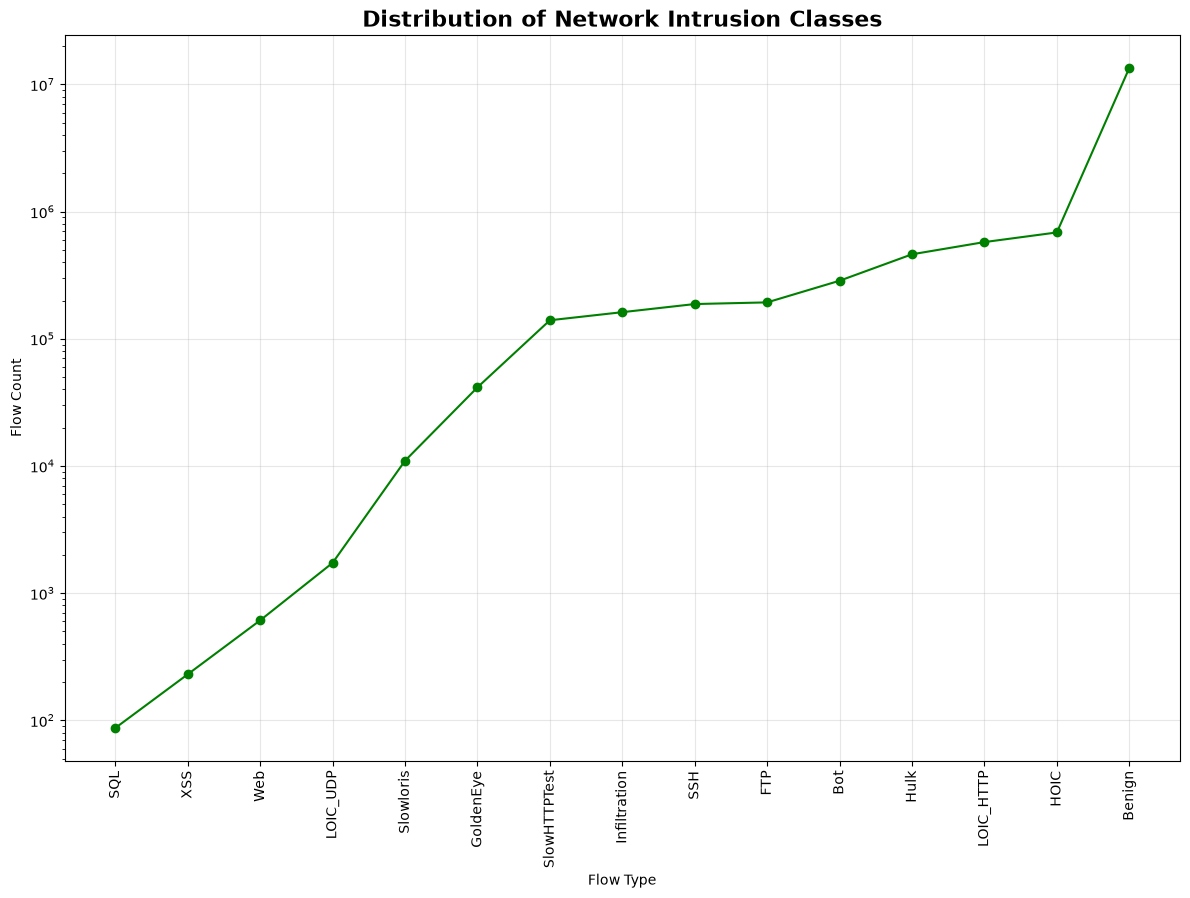

CPU times: user 1.84 s, sys: 13.8 ms, total: 1.86 s
Wall time: 1.97 s


In [14]:
%%time

plot_data = df['Label_Short'].value_counts(ascending=True)

log_scale(
    plot_data,
    "Distribution of Network Intrusion Classes",
    "Flow Type",
    "Flow Count"
)

## Pie Chart

Show ratio between Benign and Malicious flows, available in CSE-CIC-IDS2018

In [15]:
def format_class_data(df, count = 0):
    """Format dataframe into binary classification of benign and malicious"""
    for x in df.index:
        if x != "Benign":
            count += df[x]

    labels = ["Benign", "Malicious"]
    values = [df["Benign"], count]

    return labels, values

In [16]:
def pie_plot(labels, values, title):
    """Pie plot to show benign vs malicious flow record distribution"""
    plt.clf() # Clear canvas before plottting
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.tight_layout()
    plt.title(label=f"{title}", fontsize = 16, fontweight="bold")
    ax.pie(values, labels=labels, autopct='%1.0f%%',
           wedgeprops = {"edgecolor": "black",
                         "linewidth": 1,
                         "antialiased": True})
    ax.legend()
    fig.savefig(f"images/{title}.png", bbox_inches="tight")

CPU times: user 1.15 s, sys: 7.81 ms, total: 1.16 s
Wall time: 1.19 s


<Figure size 640x480 with 0 Axes>

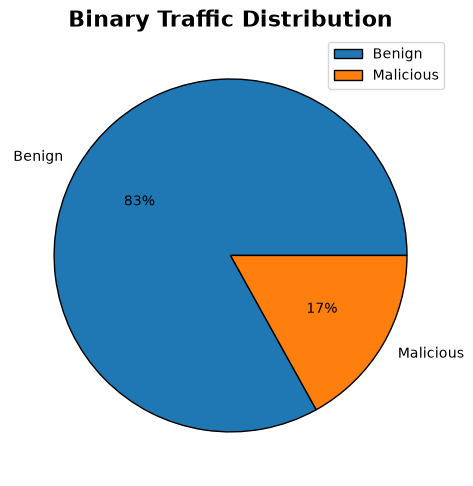

In [17]:
%%time

labels, values = format_class_data(df['Label_Short'].value_counts())

pie_plot(
    labels,
    values,
    "Binary Traffic Distribution"
)

## Protocol Chart

Chart of network protocols for which the flows are initiated

0 - protocol not assigned (possibly ICMP)<br/>
6 - TCP<br/>
17 - UDP

In [18]:
df['Protocol'].unique()

array([ 6,  0, 17])

In [19]:
df['Protocol'].value_counts()

Protocol
6     11800335
17     4194295
0       238313
Name: count, dtype: int64

In [20]:
def format_protocol_data(df, labels = [], values = []):
    """Format dataframe into binary classification of benign and malicious"""
    for x in df.index:
        if x == 0:
            labels.append("Unassigned")
        elif x == 6:
            labels.append("TCP")
        elif x == 17:
            labels.append("UDP")
        values.append(df[x])

    return labels, values

CPU times: user 163 ms, sys: 1.93 ms, total: 165 ms
Wall time: 162 ms


<Figure size 640x480 with 0 Axes>

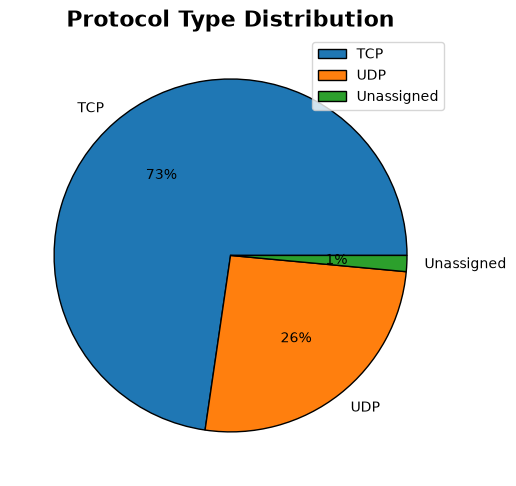

In [21]:
%%time

labels, values = format_protocol_data(df['Protocol'].value_counts())

pie_plot(
    labels,
    values,
    "Protocol Type Distribution"
)

# Cleaning Data

Objectives include:
1. Delete session info (Dst Port, Timestamp).
2. Delete rows with columns containing Infinity / NaN values.
3. Remove duplicated rows.

## Delete Session Info

Delete columns that have session info of flow data collection (Dst Port, Timestamp)

In [22]:
print(f"Column count before deletion: {len(df.columns)}")

Column count before deletion: 81


In [23]:
%%time

df.drop(['Dst Port', 'Timestamp'], axis=1, inplace=True)

CPU times: user 113 ms, sys: 11.9 ms, total: 125 ms
Wall time: 125 ms


In [24]:
print(f"Column count after deletion: {len(df.columns)}")

Column count after deletion: 79


## Dealing With Missing Values

Analyze the dataset for rows that contain NaN or Infinity values

In [25]:
%%time

nan_values = {key: value for key, value in df.isna().sum().items() if value > 0}

print(nan_values)

{'Flow Byts/s': 59721}
CPU times: user 1.83 s, sys: 4.78 ms, total: 1.84 s
Wall time: 1.83 s


Filter for infinity values and replace them as NaN

In [26]:
%%time

df.replace([np.inf, -np.inf], np.nan, inplace=True)

CPU times: user 2.43 s, sys: 1.93 s, total: 4.37 s
Wall time: 4.39 s


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label_Short
0,6,141385,9,7,553.0,3773.0,202.0,0.0,61.444444,87.534438,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
1,6,281,2,1,38.0,0.0,38.0,0.0,19.000000,26.870058,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
2,6,279824,11,15,1086.0,10527.0,385.0,0.0,98.727273,129.392497,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
3,6,132,2,0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
4,6,274016,9,13,1285.0,6141.0,517.0,0.0,142.777778,183.887722,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16232938,6,3,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infilteration,Infiltration
16232939,6,2,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infilteration,Infiltration
16232940,6,732728,2,2,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
16232941,6,22,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infilteration,Infiltration


Updated list of NaN values

In [27]:
%%time

nan_values = {key: value for key, value in df.isna().sum().items() if value > 0}

print(nan_values)

{'Flow Byts/s': 95760, 'Flow Pkts/s': 95760}
CPU times: user 1.9 s, sys: 7.48 ms, total: 1.91 s
Wall time: 1.91 s


Create a bar plot to visualize NaN data

In [28]:
def nan_plot(_dict, title, xlabel, ylabel):
    """Bar plot for NaN values"""
    bar_labels = [_dict['Flow Byts/s'], _dict['Flow Pkts/s']]

    fig, ax = plt.subplots(figsize=(10,10))
    ax.grid(
        True,
        alpha=0.3
    )
    ax.bar(
        _dict.keys(),
        _dict.values(),
        zorder=3
    )
    for container in ax.containers:
        ax.bar_label(container, labels=bar_labels)
    ax.set_title(
        f"{title}",
        fontsize=16,
        fontweight="bold"
    )
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")
    fig.savefig(
        f"images/{title}.png",
        bbox_inches="tight"
    )

CPU times: user 91.8 ms, sys: 2.02 ms, total: 93.8 ms
Wall time: 96 ms


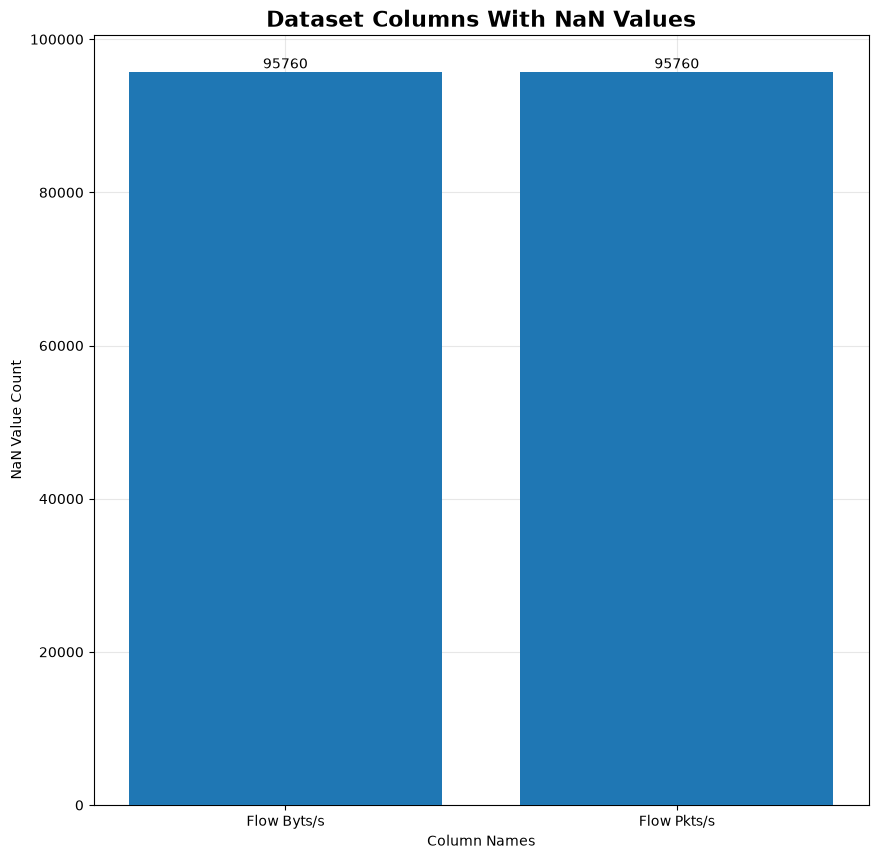

In [29]:
%%time

nan_plot(
    nan_values,
    "Dataset Columns With NaN Values",
    "Column Names",
    "NaN Value Count"
)

Delete rows that contain NaN values

In [30]:
%%time

before = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 20 s, sys: 13.3 ms, total: 20 s
Wall time: 20.1 s


In [31]:
%%time

df.dropna(inplace=True)
df = df.reset_index(drop=True)

CPU times: user 3.17 s, sys: 451 ms, total: 3.62 s
Wall time: 3.66 s


In [32]:
%%time

after = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 19.9 s, sys: 34.3 ms, total: 19.9 s
Wall time: 20 s


In [33]:
total = 0
for (k, v), (k2, v2) in zip(before.items(), after.items()):
    print(f"{k} has {v - v2} rows dropped")
    total += v - v2
print(f"Total rows dropped: {total}")

Benign has 94459 rows dropped
DDOS attack-HOIC has 0 rows dropped
DDoS attacks-LOIC-HTTP has 0 rows dropped
DoS attacks-Hulk has 0 rows dropped
Bot has 0 rows dropped
FTP-BruteForce has 6 rows dropped
SSH-Bruteforce has 0 rows dropped
Infilteration has 1295 rows dropped
DoS attacks-SlowHTTPTest has 0 rows dropped
DoS attacks-GoldenEye has 0 rows dropped
DoS attacks-Slowloris has 0 rows dropped
DDOS attack-LOIC-UDP has 0 rows dropped
Brute Force -Web has 0 rows dropped
Brute Force -XSS has 0 rows dropped
SQL Injection has 0 rows dropped
Total rows dropped: 95760


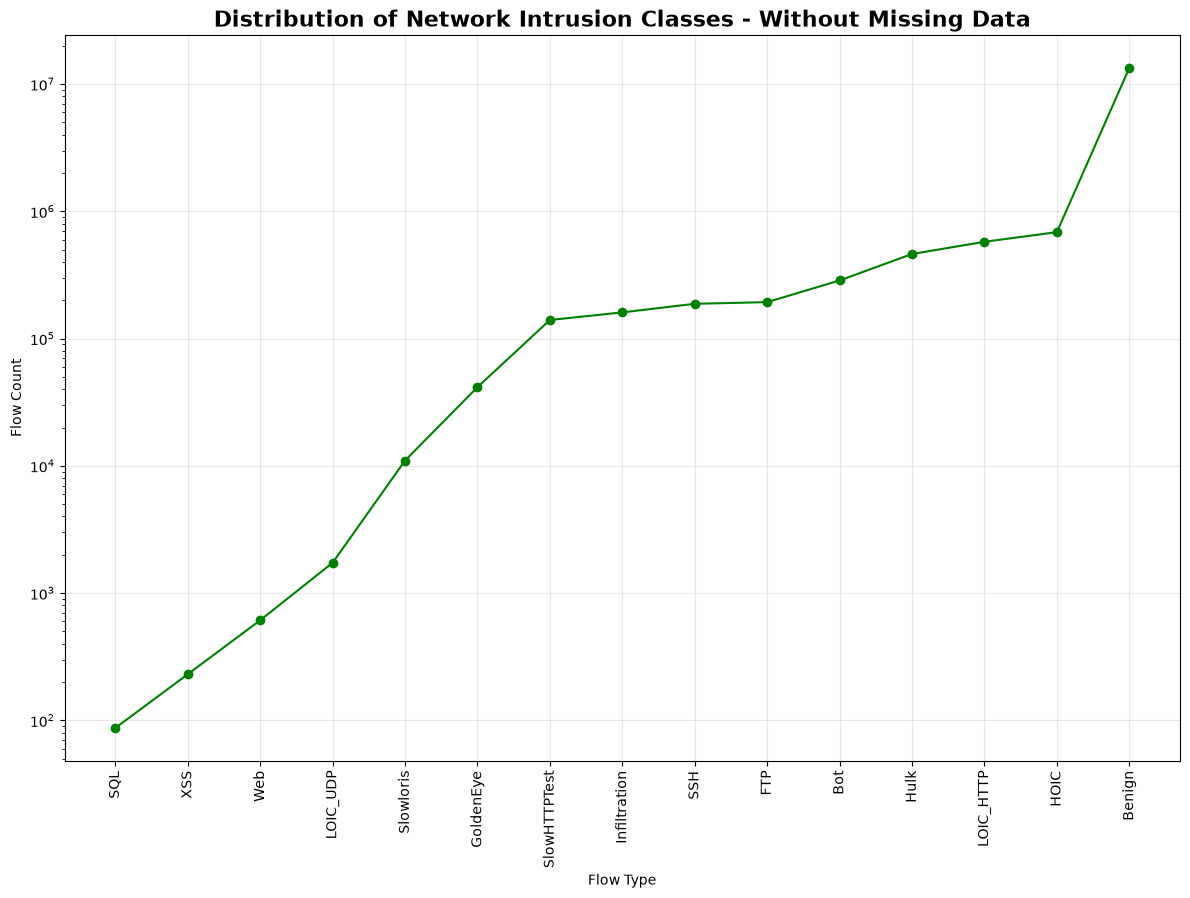

CPU times: user 1.65 s, sys: 17.8 ms, total: 1.67 s
Wall time: 1.66 s


In [34]:
%%time

plot_data = df['Label_Short'].value_counts(ascending=True)

log_scale(
    plot_data,
    "Distribution of Network Intrusion Classes - Without Missing Data",
    "Flow Type",
    "Flow Count"
)

## Drop Duplicates

In [35]:
%%time

before = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 20 s, sys: 17.3 ms, total: 20 s
Wall time: 20 s


In [36]:
%%time

df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)

CPU times: user 1min 16s, sys: 2.15 s, total: 1min 18s
Wall time: 1min 18s


In [37]:
%%time

after = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 13.4 s, sys: 9.68 ms, total: 13.4 s
Wall time: 13.4 s


In [38]:
total = 0
for (k, v), (k2, v2) in zip(before.items(), after.items()):
    print(f"{k} has {v - v2} rows dropped")
    total += v - v2
print(f"Total rows dropped: {total}")

Benign has 3897052 rows dropped
DDOS attack-HOIC has 110648 rows dropped
DDoS attacks-LOIC-HTTP has 377330 rows dropped
DoS attacks-Hulk has 316713 rows dropped
Bot has 141656 rows dropped
FTP-BruteForce has 79535 rows dropped
SSH-Bruteforce has 93541 rows dropped
Infilteration has 119233 rows dropped
DoS attacks-SlowHTTPTest has 129982 rows dropped
DoS attacks-GoldenEye has 39778 rows dropped
DoS attacks-Slowloris has 10435 rows dropped
DDOS attack-LOIC-UDP has 1502 rows dropped
Brute Force -Web has 527 rows dropped
Brute Force -XSS has 175 rows dropped
SQL Injection has 34 rows dropped
Total rows dropped: 5318141


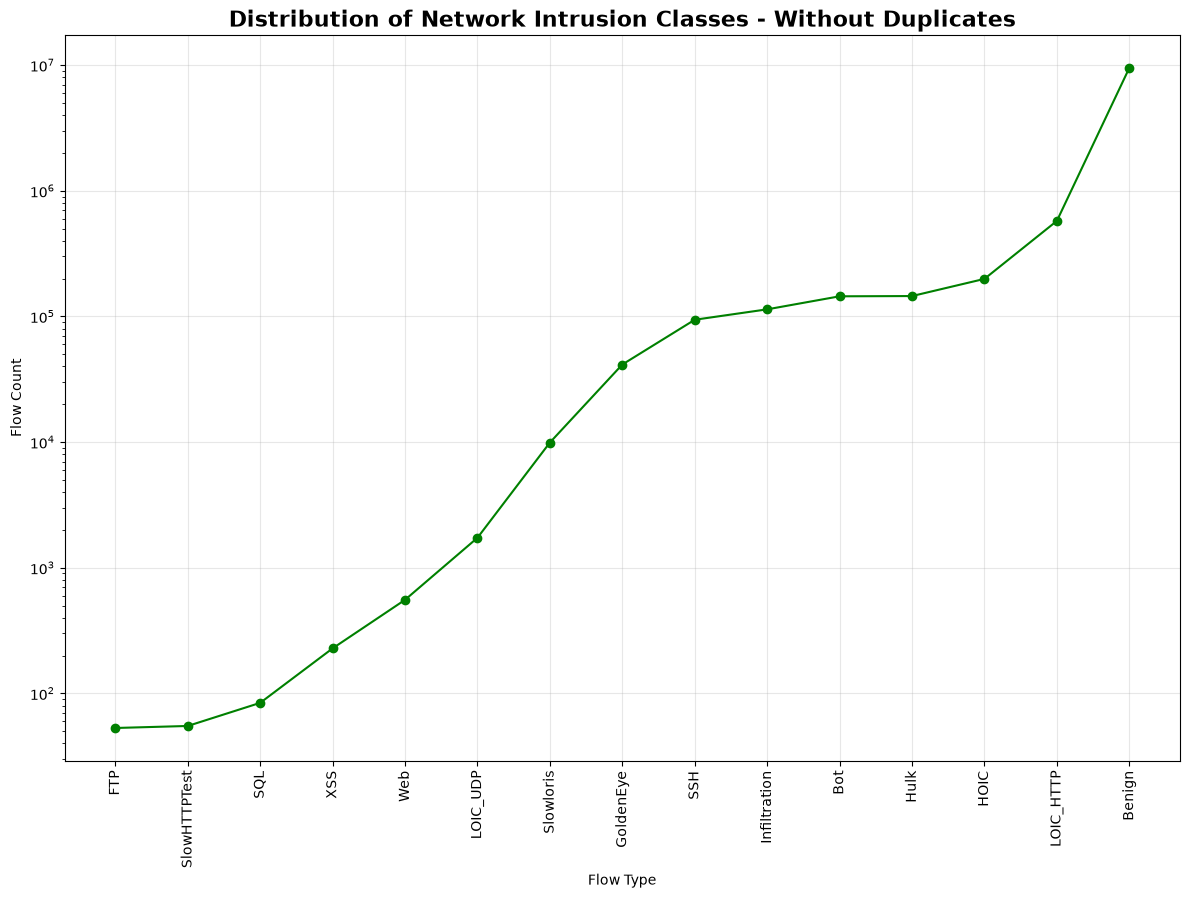

CPU times: user 1.32 s, sys: 17.5 ms, total: 1.34 s
Wall time: 1.33 s


In [39]:
%%time

plot_data = df['Label_Short'].value_counts(ascending=True)

log_scale(
    plot_data,
    "Distribution of Network Intrusion Classes - Without Duplicates",
    "Flow Type",
    "Flow Count"
)

# Feature Selection

Trim features:
1. Remove features with zero variance.
2. Remove highly correlated features.
3. Compute feature importance with XGBoost.

## Zero Variance Columns

Drop features with zero variance

In [40]:
%%time

zero_variance_cols = df.columns[df.nunique() <= 1]
print(f"Columns with zero variance: {len(zero_variance_cols)}\nColumn names: {zero_variance_cols.tolist()}\nDtype: {zero_variance_cols.dtype}")

Columns with zero variance: 8
Column names: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
Dtype: str
CPU times: user 17 s, sys: 1.75 ms, total: 17 s
Wall time: 17.1 s


In [41]:
%%time

df.drop(zero_variance_cols, axis=1, inplace=True)

CPU times: user 248 ms, sys: 7.94 ms, total: 256 ms
Wall time: 246 ms


In [42]:
print(f"Columns left: {len(df.columns)}")

Columns left: 71


## Calculate Correlation

Figure out and drop features that are highly correlated (|r| > 0.95) 

In [43]:
%%time

correlation_data = df.corr(method='spearman', numeric_only=True)

CPU times: user 5min 12s, sys: 5.72 s, total: 5min 18s
Wall time: 5min 20s


In [44]:
def full_correlation_heatmap(correlation_data, title, columns):
    """Plot a correlation heatmap for all available features"""
    fig, ax = plt.subplots(figsize=(16, 14))

    im = ax.imshow(
        correlation_data,
        vmin=-1,
        vmax=1,
        aspect="equal"
    )

    # Feature names
    ax.set_xticks(np.arange(len(columns)))
    ax.set_yticks(np.arange(len(columns)))

    ax.set_xticklabels(
        columns,
        rotation=90,
        fontsize=8
    )
    ax.set_yticklabels(
        columns,
        fontsize=8
    )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(
        f"Spearman Correlation (ρ)",
        fontsize=12
    )

    ax.set_title(
        f"{title}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

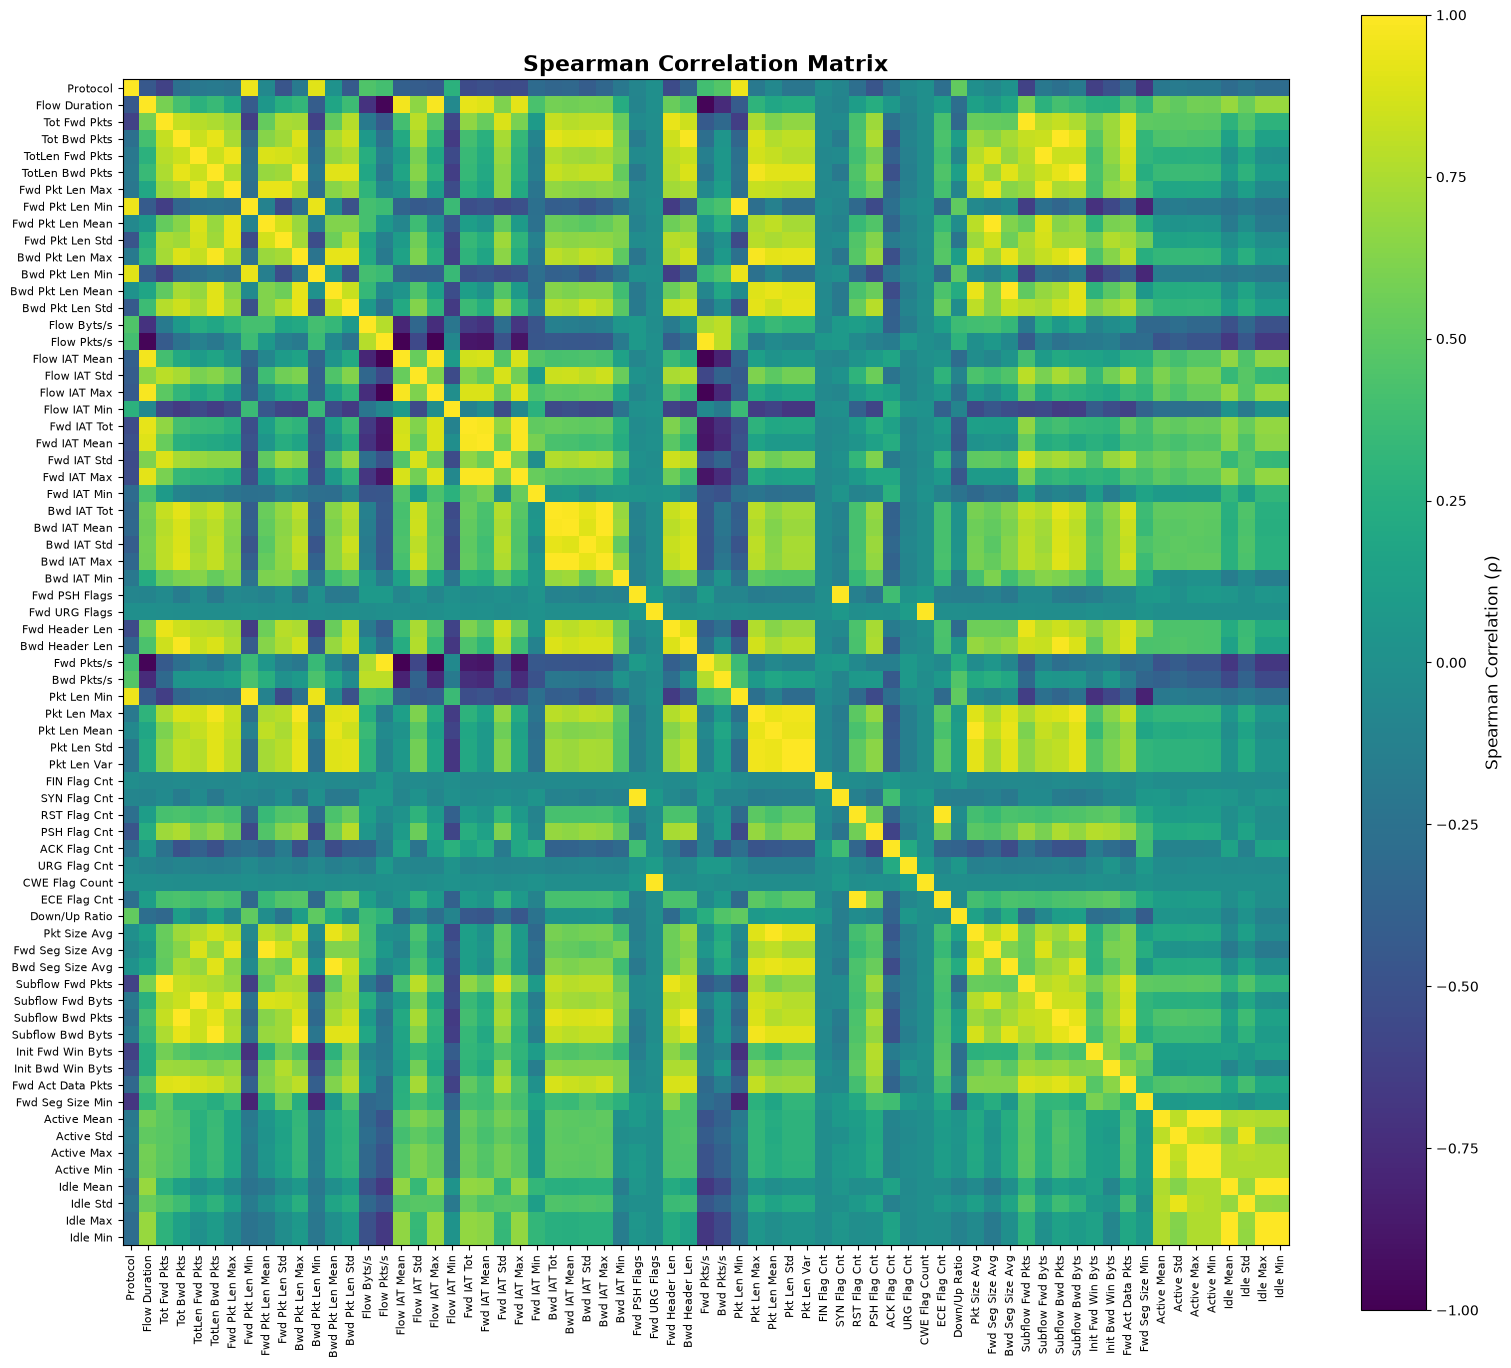

CPU times: user 949 ms, sys: 271 ms, total: 1.22 s
Wall time: 1.42 s


In [45]:
%%time

correlation_columns = correlation_data.columns
full_correlation_heatmap(correlation_data, "Spearman Correlation Matrix", correlation_columns)

In [46]:
correlation_data

,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Protocol,1.000000,-0.452326,-0.605857,-0.260492,-0.196533,-0.175459,-0.206975,0.946582,-0.066270,-0.472840,...,-0.320403,-0.682946,-0.198249,-0.166177,-0.198312,-0.198294,-0.291080,-0.233797,-0.290851,-0.290619
Flow Duration,-0.452326,1.000000,0.591319,0.412052,0.288346,0.355245,0.199648,-0.424163,0.054970,0.253377,...,0.455243,0.316514,0.569968,0.508048,0.572102,0.567686,0.692828,0.542724,0.693107,0.691541
Tot Fwd Pkts,-0.605857,0.591319,1.000000,0.822671,0.782098,0.753887,0.695020,-0.627264,0.528202,0.744666,...,0.893269,0.503758,0.494396,0.488097,0.499381,0.489173,0.293484,0.459064,0.294483,0.291001
Tot Bwd Pkts,-0.260492,0.412052,0.822671,1.000000,0.841364,0.925535,0.745768,-0.337012,0.639637,0.714555,...,0.907395,0.323446,0.437877,0.456693,0.443288,0.432283,0.140701,0.382511,0.141213,0.140875
TotLen Fwd Pkts,-0.196533,0.288346,0.782098,0.841364,1.000000,0.839811,0.947822,-0.259734,0.887355,0.867344,...,0.873117,0.312711,0.266639,0.263873,0.269318,0.260708,0.008589,0.199593,0.009441,0.007537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Active Min,-0.198294,0.567686,0.489173,0.432283,0.260708,0.353037,0.182598,-0.187791,0.038509,0.162870,...,0.438303,0.105231,0.997864,0.778263,0.995210,1.000000,0.763309,0.758815,0.764954,0.760942
Idle Mean,-0.291080,0.692828,0.293484,0.140701,0.008589,0.096305,-0.053092,-0.236718,-0.175248,-0.021866,...,0.188890,0.082215,0.763147,0.628946,0.761728,0.763309,1.000000,0.681508,0.999492,0.999281
Idle Std,-0.233797,0.542724,0.459064,0.382511,0.199593,0.291989,0.123284,-0.166573,-0.023049,0.102834,...,0.401863,0.005079,0.774216,0.933258,0.788435,0.758815,0.681508,1.000000,0.686896,0.672280
Idle Max,-0.290851,0.693107,0.294483,0.141213,0.009441,0.096752,-0.052876,-0.236306,-0.174774,-0.022033,...,0.189345,0.082278,0.765113,0.632515,0.763824,0.764954,0.999492,0.686896,1.000000,0.998227


Create a numpy array that keeps only the highly correlated features of the upper triangle
Everything else is set to `nan`

In [47]:
%%time

threshold = 0.95

numpy_matrix = correlation_data.to_numpy().copy()
numpy_matrix[np.abs(numpy_matrix) < threshold] = np.nan # Keep only strong correlations
numpy_matrix[np.tril_indices_from(numpy_matrix, k=-1)] = np.nan

CPU times: user 642 μs, sys: 398 μs, total: 1.04 ms
Wall time: 666 μs


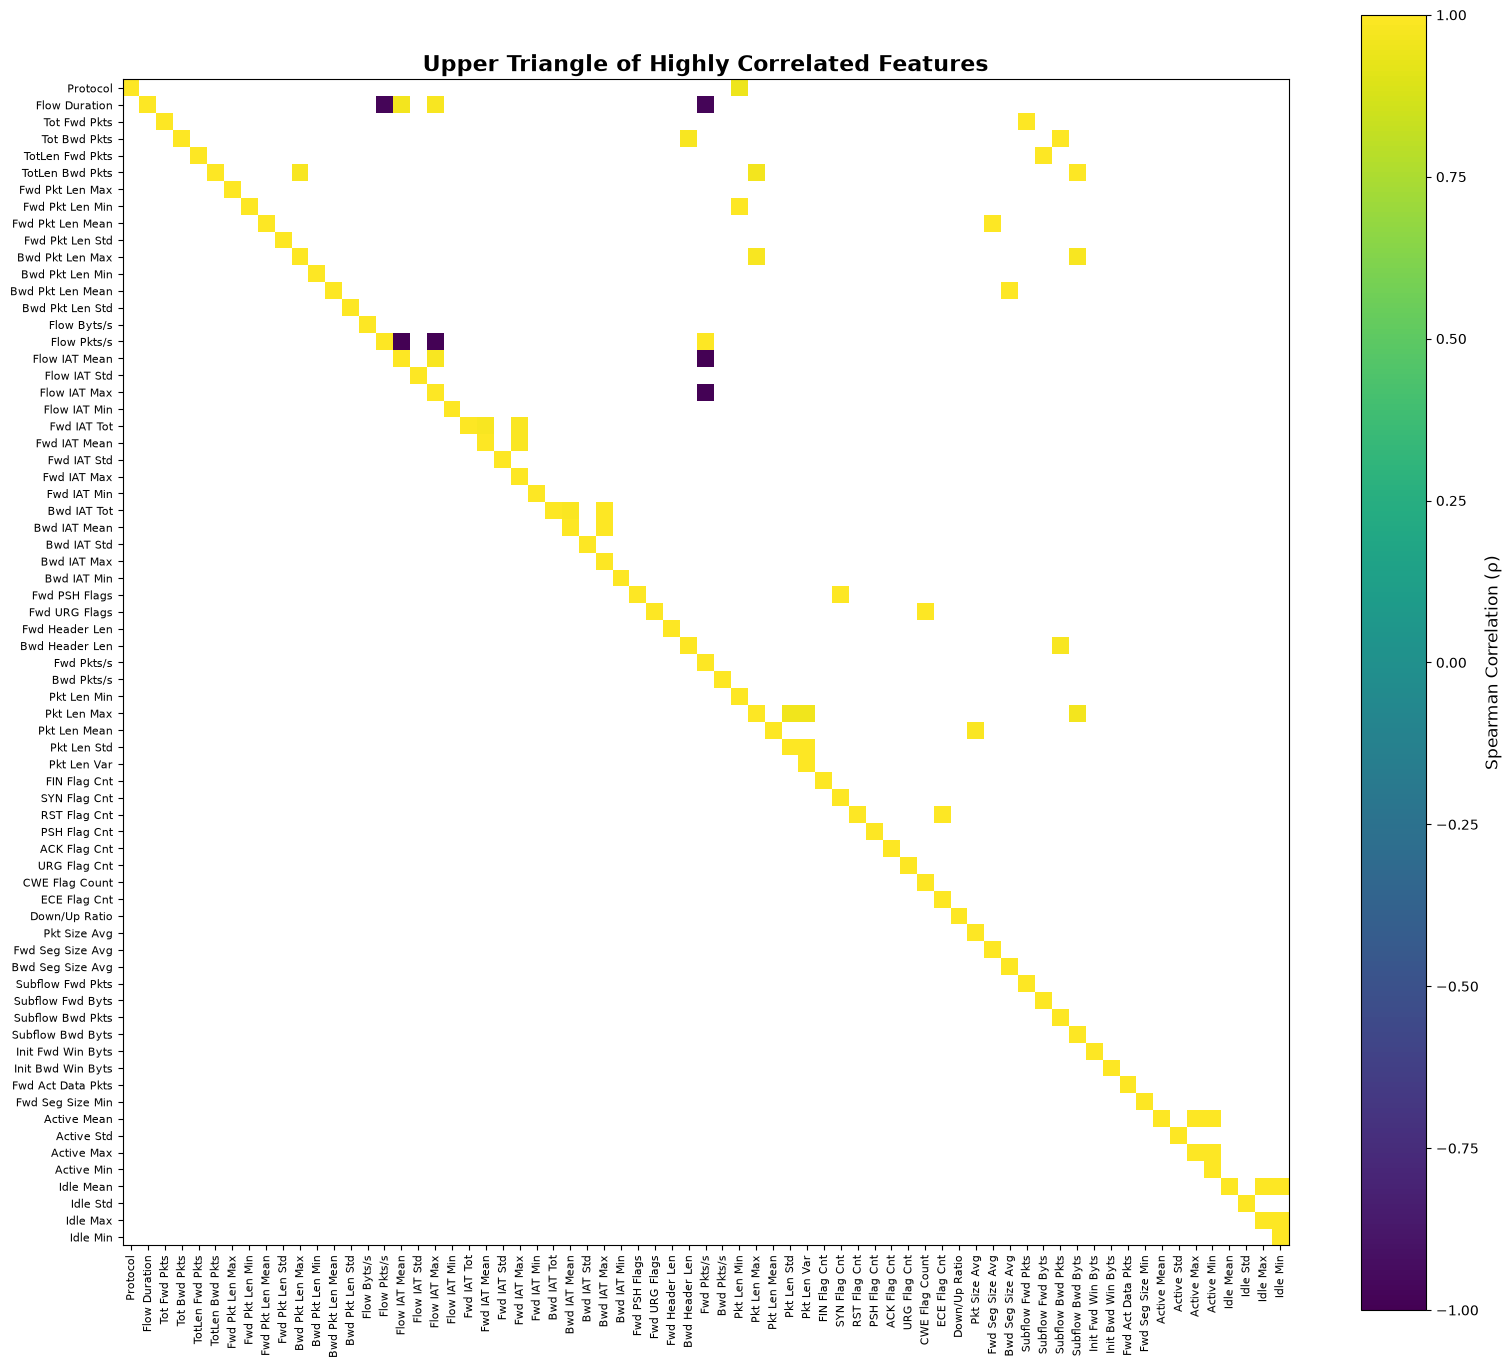

CPU times: user 899 ms, sys: 39.8 ms, total: 939 ms
Wall time: 940 ms


In [48]:
%%time

full_correlation_heatmap(numpy_matrix, "Upper Triangle of Highly Correlated Features", correlation_columns)

Print correlated features

In [49]:
def correlatedColumns(correlation_data):
    """Print correlated columns and their correlation coefficients"""
    rows, cols = np.where(np.triu(correlation_data.to_numpy() > threshold, k=1))

    for r, c in zip(rows, cols):
        row_name = correlation_data.index[r]
        column_name = correlation_data.columns[c]
        print(f"{row_name} <-> {column_name} ({correlation_data[row_name][column_name]})")

In [50]:
%%time

correlatedColumns(correlation_data)

Protocol <-> Pkt Len Min (0.9503884375707666)
Flow Duration <-> Flow IAT Mean (0.9627528119288769)
Flow Duration <-> Flow IAT Max (0.9815519016500263)
Tot Fwd Pkts <-> Subflow Fwd Pkts (1.0)
Tot Bwd Pkts <-> Bwd Header Len (0.9793900561364284)
Tot Bwd Pkts <-> Subflow Bwd Pkts (1.0)
TotLen Fwd Pkts <-> Subflow Fwd Byts (1.0)
TotLen Bwd Pkts <-> Bwd Pkt Len Max (0.9842607139193905)
TotLen Bwd Pkts <-> Pkt Len Max (0.9656178052279001)
TotLen Bwd Pkts <-> Subflow Bwd Byts (0.9999999999999999)
Fwd Pkt Len Min <-> Pkt Len Min (0.9959373625075433)
Fwd Pkt Len Mean <-> Fwd Seg Size Avg (0.9999986525226356)
Bwd Pkt Len Max <-> Pkt Len Max (0.9820844226839204)
Bwd Pkt Len Max <-> Subflow Bwd Byts (0.9842607139193937)
Bwd Pkt Len Mean <-> Bwd Seg Size Avg (0.9999999203420457)
Flow Pkts/s <-> Fwd Pkts/s (0.9972767593636969)
Flow IAT Mean <-> Flow IAT Max (0.9791338737571453)
Fwd IAT Tot <-> Fwd IAT Mean (0.9779519636068693)
Fwd IAT Tot <-> Fwd IAT Max (0.988649866957735)
Fwd IAT Mean <-> Fwd IAT 

In [51]:
correlated_features_to_drop = [
    'Flow IAT Mean',
    'Flow IAT Max',
    'Fwd IAT Tot',
    'Fwd IAT Max',
    'Bwd IAT Tot',
    'Bwd IAT Max',
    'Active Max',
    'Active Min',
    'Idle Max',
    'Idle Min',
    'Subflow Fwd Pkts',
    'Subflow Bwd Pkts',
    'Bwd Header Len',
    'Fwd Pkts/s',
    'Bwd Pkt Len Max',
    'Bwd Pkt Len Mean',
    'Pkt Len Max',
    'Pkt Len Mean',
    'Pkt Len Var',
    'Pkt Size Avg',
    'Bwd Seg Size Avg',
    'Subflow Bwd Byts',
    'Fwd Pkt Len Max',
    'Fwd Seg Size Avg',
    'Subflow Fwd Byts',
    'Fwd Pkt Len Min',
    'ECE Flag Cnt',
    'Fwd PSH Flags',
    'CWE Flag Count'
]

In [52]:
print(f"Features before dropping correlated features: {len(df.columns)}")

Features before dropping correlated features: 71


In [53]:
df.drop(correlated_features_to_drop, axis=1, inplace=True)

In [54]:
print(f"Features after dropping correlated features: {len(df.columns)}")

Features after dropping correlated features: 42


## Feature Importance

Use XGBoost on a stratified dataset subsample to figure out which features have a highest influence on classification decisions

As a baseline benchmark of feature importance, add 10 columns with random data 

In [55]:
rng = np.random.default_rng(42)

for i in range(10):
    df[f"random_probe_{i}"] = rng.random(len(df))

In [56]:
labels = df['Label']

In [57]:
features = df.drop(['Label', 'Label_Short'], axis=1)

In [58]:
labels

0                  Benign
1                  Benign
2                  Benign
3                  Benign
4                  Benign
                ...      
10819037    Infilteration
10819038           Benign
10819039           Benign
10819040           Benign
10819041    Infilteration
Name: Label, Length: 10819042, dtype: str

In [59]:
features.head()

,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Min,Bwd Pkt Len Std,...,random_probe_0,random_probe_1,random_probe_2,random_probe_3,random_probe_4,random_probe_5,random_probe_6,random_probe_7,random_probe_8,random_probe_9
0,6,141385,9,7,553.0,3773.0,61.444444,87.534438,0.0,655.432936,...,0.773956,0.292676,0.196261,0.437410,0.348179,0.700426,0.750148,0.728110,0.406957,0.579837
1,6,281,2,1,38.0,0.0,19.000000,26.870058,0.0,0.000000,...,0.438878,0.221777,0.144260,0.087048,0.160622,0.903657,0.839579,0.186865,0.625056,0.261494
2,6,279824,11,15,1086.0,10527.0,98.727273,129.392497,0.0,636.314186,...,0.858598,0.219484,0.447273,0.777165,0.744431,0.932876,0.052573,0.870575,0.296839,0.011942
3,6,132,2,0,0.0,0.0,0.000000,0.000000,0.0,0.000000,...,0.697368,0.414578,0.449153,0.739755,0.329807,0.406170,0.287110,0.470149,0.851512,0.714965
4,6,274016,9,13,1285.0,6141.0,142.777778,183.887722,0.0,611.180489,...,0.094177,0.389589,0.280306,0.139249,0.213357,0.758375,0.670412,0.812281,0.168789,0.175626


In [60]:
%%time

le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

CPU times: user 1.1 s, sys: 162 ms, total: 1.26 s
Wall time: 1.28 s


In [61]:
encoded_labels

array([ 0,  0,  0, ...,  0,  0, 12], shape=(10819042,))

In [62]:
df['Encoded_Label'] = encoded_labels

In [63]:
params = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',

    'n_estimators': 300,
    'max_depth': 4,

    'learning_rate': 0.05,

    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'colsample_bylevel': 0.8,

    'min_child_weight': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.5,

    'tree_method': 'hist',
}

Retrain XGBoost classifier with 5 different seeds for train/test data split and XGBoost randomness

Data collected:
1. For each feature, collect feature importance metrics:
    * Gain
    * Weight
    * Cover
    * Relative Importance
    * Rank
2. For each metric, collect values and compute:
    * Standard Deviation
    * Mean
    * Coefficient of Variance

Results are written to JSON file

In [64]:
def serializeNumpy(obj):
    """Serialize Numpy value of any type to JSON"""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

In [65]:
%%time

cv_counter = 1
cv_iterations = 5
IMPORTANCE_TYPES = ["gain", "weight", "cover"]
feature_importance_stats = {}

for columns in features.columns:
    feature_importance_stats[columns] = {
        "gain": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "weight": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "cover": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "importance": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "rank": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        }
    }

params['random_state'] = 42

start = time.time()
print("Splitting dataset to train and test")
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Encoded_Label'],
    random_state=42
)

X_train = train_df.drop(columns=["Label", "Label_Short", "Encoded_Label"])
y_train = train_df["Encoded_Label"]

params['num_class'] = len(y_train.unique())
model = xgb.XGBClassifier(**params)

end = time.time()
print(f"Split finished in {end - start} seconds")

start = time.time()
print("Creating stratified K-Fold")

cv = StratifiedKFold(
    n_splits=cv_iterations,
    shuffle=True,
    random_state=42
)

end = time.time()
print(f"Creating stratified K-Fold finished in {end - start} seconds")

for train_idx, val_idx in cv.split(X_train, y_train):
    start = time.time()

    print(f"Starting CV {cv_counter}/{cv_iterations}...")

    model.fit(
        X_train.iloc[train_idx],
        y_train.iloc[train_idx]
    )

    importances_dict = {name: importance for name, importance in zip(model.feature_names_in_, model.feature_importances_)}

    importances_dict_sorted = {k: v for k, v in sorted(importances_dict.items(), key=lambda item: item[1])}

    rank = len(features.columns)

    for key, value in importances_dict_sorted.items():
        feature_importance_stats[key]["importance"]["data"].append(value)
        feature_importance_stats[key]["rank"]["data"].append(rank)
        rank -= 1

    booster = model.get_booster()
    for itype in IMPORTANCE_TYPES:
        for key, value in booster.get_score(importance_type=itype).items():
            feature_importance_stats[key][itype]["data"].append(value)

    end = time.time()
    print(f"CV iteration {cv_counter}/{cv_iterations} finished in {end - start} seconds")
    cv_counter += 1

for column in feature_importance_stats:
    for key in feature_importance_stats[column]:
        data = feature_importance_stats[column][key]["data"]
        std = np.std(data)
        feature_importance_stats[column][key]["std"] = std
        mean = np.mean(data)
        feature_importance_stats[column][key]["mean"] = mean
        cv = (std / mean) * 100
        feature_importance_stats[column][key]["cv"] = cv

# Write statistics to a JSON file
with open("data.json", "w") as f:
    f.write(json.dumps(feature_importance_stats, default=serializeNumpy, indent=4))

Splitting dataset to train and test
Split finished in 10.503732681274414 seconds
Creating stratified K-Fold
Creating stratified K-Fold finished in 1.9311904907226562e-05 seconds
Starting CV 1/5...
CV iteration 1/5 finished in 1354.1298296451569 seconds
Starting CV 2/5...
CV iteration 2/5 finished in 1328.8320281505585 seconds
Starting CV 3/5...
CV iteration 3/5 finished in 1351.8142013549805 seconds
Starting CV 4/5...
CV iteration 4/5 finished in 1436.0017738342285 seconds
Starting CV 5/5...
CV iteration 5/5 finished in 1359.204191684723 seconds
CPU times: user 14h 35min 38s, sys: 58.4 s, total: 14h 36min 36s
Wall time: 1h 54min 1s


# Plotting Feature Statistics

For every statistical feature, plot the following:
1. Log plot:
    * Coefficient of Variance (CV)
    * Mean
2. Scatterplot (CV + Mean)

In [66]:
gain_mean, gain_cv, weight_mean, weight_cv, cover_mean, cover_cv, importance_mean, importance_cv, rank_mean, rank_cv = [{} for x in range(10)]

In [67]:
for column in feature_importance_stats.keys():
    for metric in feature_importance_stats[column].keys():
        mean = feature_importance_stats[column][metric]["mean"]
        cv = feature_importance_stats[column][metric]["cv"]
        if metric == "gain":
            gain_mean[column] = mean
            gain_cv[column] = cv
        elif metric == "weight":
            weight_mean[column] = mean
            weight_cv[column] = cv
        elif metric == "cover":
            cover_mean[column] = mean
            cover_cv[column] = cv
        elif metric == "importance":
            importance_mean[column] = mean
            importance_cv[column] = cv
        elif metric == "rank":
            rank_mean[column] = mean
            rank_cv[column] = cv

In [68]:
gain_mean_sorted = {k: v for k, v in sorted(gain_mean.items(), key=lambda item: item[1])}
gain_cv_sorted = {k: v for k, v in sorted(gain_cv.items(), key=lambda item: item[1])}
weight_mean_sorted = {k: v for k, v in sorted(weight_mean.items(), key=lambda item: item[1])}
weight_cv_sorted = {k: v for k, v in sorted(weight_cv.items(), key=lambda item: item[1])}
cover_mean_sorted = {k: v for k, v in sorted(cover_mean.items(), key=lambda item: item[1])}
cover_cv_sorted = {k: v for k, v in sorted(cover_cv.items(), key=lambda item: item[1])}
importance_mean_sorted = {k: v for k, v in sorted(importance_mean.items(), key=lambda item: item[1])}
importance_cv_sorted = {k: v for k, v in sorted(importance_cv.items(), key=lambda item: item[1])}
rank_mean_sorted = {k: v for k, v in sorted(rank_mean.items(), key=lambda item: item[1])}
rank_cv_sorted = {k: v for k, v in sorted(rank_cv.items(), key=lambda item: item[1])}

In [69]:
def feature_importance(plot_data, title, xlabel, ylabel, threshold):
    """Coefficient of variance for XGBoost-ranked variables"""
    x, y = [[] for z in range(2)]
    length = len(plot_data.items()) - 1
    for key, value in plot_data.items():
        x.append(key)
        y.append(value)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.grid(True, alpha=0.3)
    ax.set_yscale("log")  # Convert y-axis to logarithmic scale
    ax.plot(x, y, "o-", color="green")
    if threshold > 0:
        ax.plot([0, length], [threshold, threshold], "k--")
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")
    fig.tight_layout()
    plt.xticks(rotation=90)
    plt.title(f"{title}", fontsize = 16, fontweight="bold")
    plt.show()
    fig.savefig(f"images/{title}.png", bbox_inches="tight")
    fig.clear()
    plt.close(fig)

## Mean and CV Plots

In [100]:
random_columns = [f"random_probe_{x}" for x in range(10)]

gain_mean_threshold = np.max([gain_mean_sorted[x] for x in random_columns])
gain_cv_threshold = np.max([gain_cv_sorted[x] for x in random_columns])
weight_mean_threshold = np.max([weight_mean_sorted[x] for x in random_columns])
weight_cv_threshold = np.max([weight_cv_sorted[x] for x in random_columns])
cover_mean_threshold = np.max([cover_mean_sorted[x] for x in random_columns])
cover_cv_threshold = np.max([cover_cv_sorted[x] for x in random_columns])
importance_mean_threshold = np.max([importance_mean_sorted[x] for x in random_columns])
importance_cv_threshold = np.max([importance_cv_sorted[x] for x in random_columns])
rank_mean_threshold = np.min([rank_mean_sorted[x] for x in random_columns])
rank_cv_threshold = np.min([rank_cv_sorted[x] for x in random_columns])

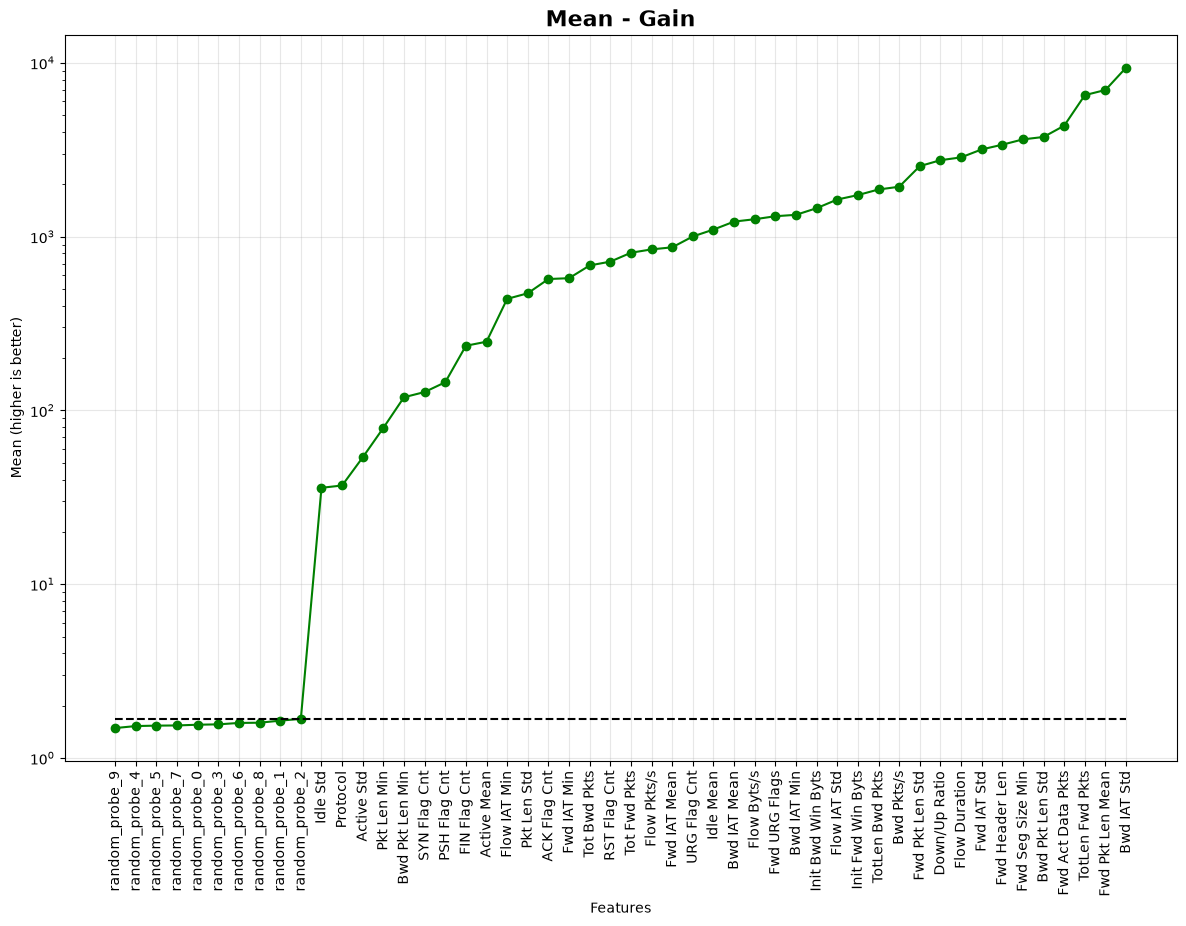

CPU times: user 904 ms, sys: 52.3 ms, total: 956 ms
Wall time: 986 ms


In [71]:
%%time

feature_importance(
    gain_mean_sorted,
    "Mean - Gain",
    "Features",
    "Mean (higher is better)",
    gain_mean_threshold
)

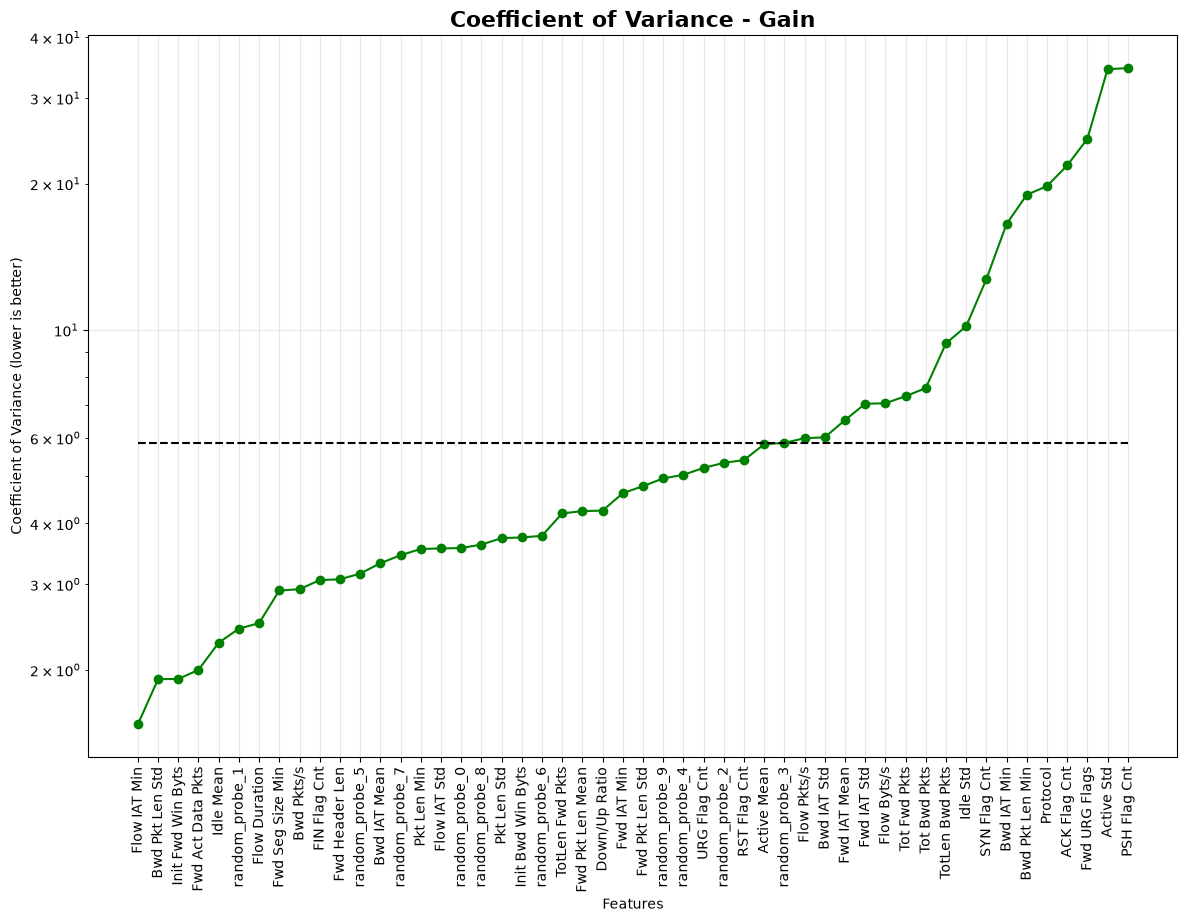

CPU times: user 865 ms, sys: 35.3 ms, total: 901 ms
Wall time: 911 ms


In [72]:
%%time

feature_importance(
    gain_cv_sorted,
    "Coefficient of Variance - Gain",
    "Features",
    "Coefficient of Variance (lower is better)",
    gain_cv_threshold
)

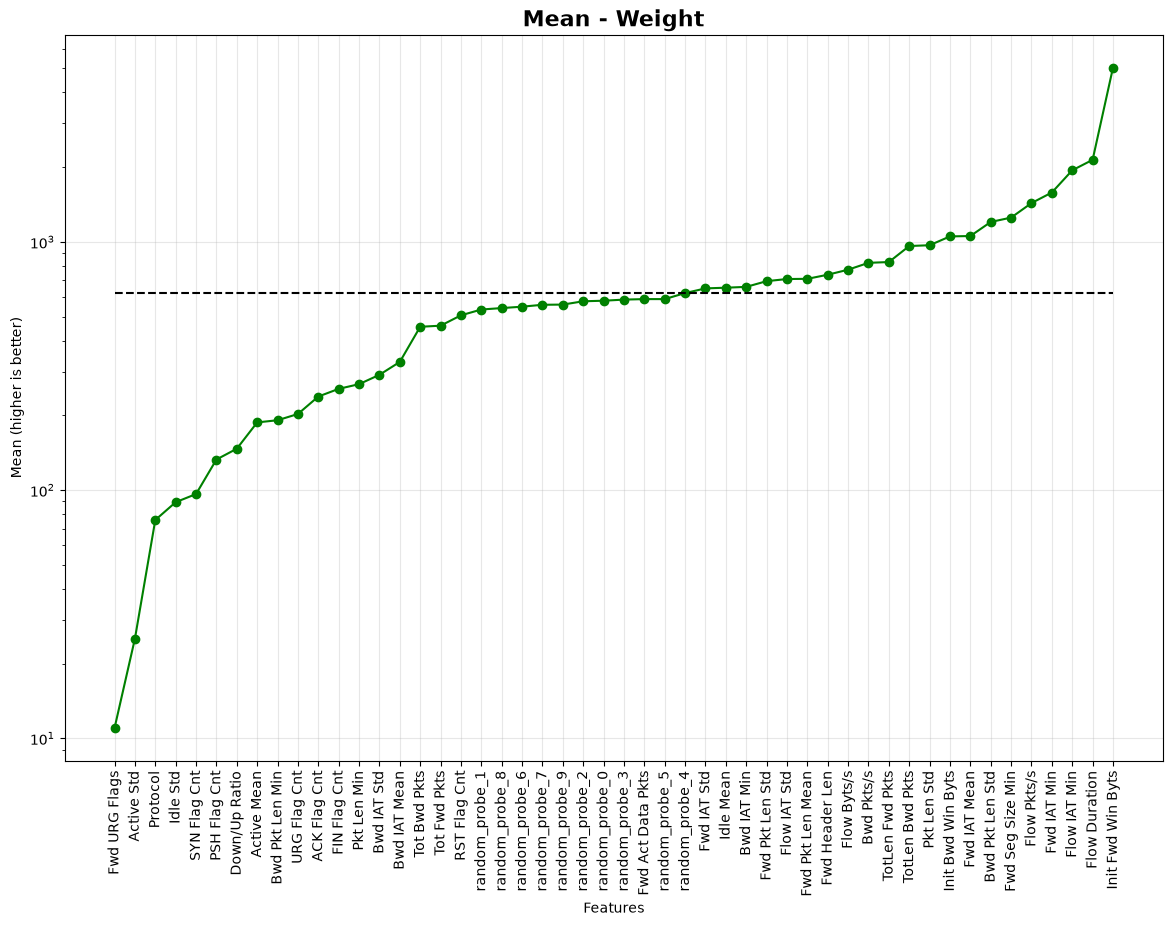

CPU times: user 813 ms, sys: 36.8 ms, total: 849 ms
Wall time: 850 ms


In [73]:
%%time

feature_importance(
    weight_mean_sorted,
    "Mean - Weight",
    "Features",
    "Mean (higher is better)",
    weight_mean_threshold
)

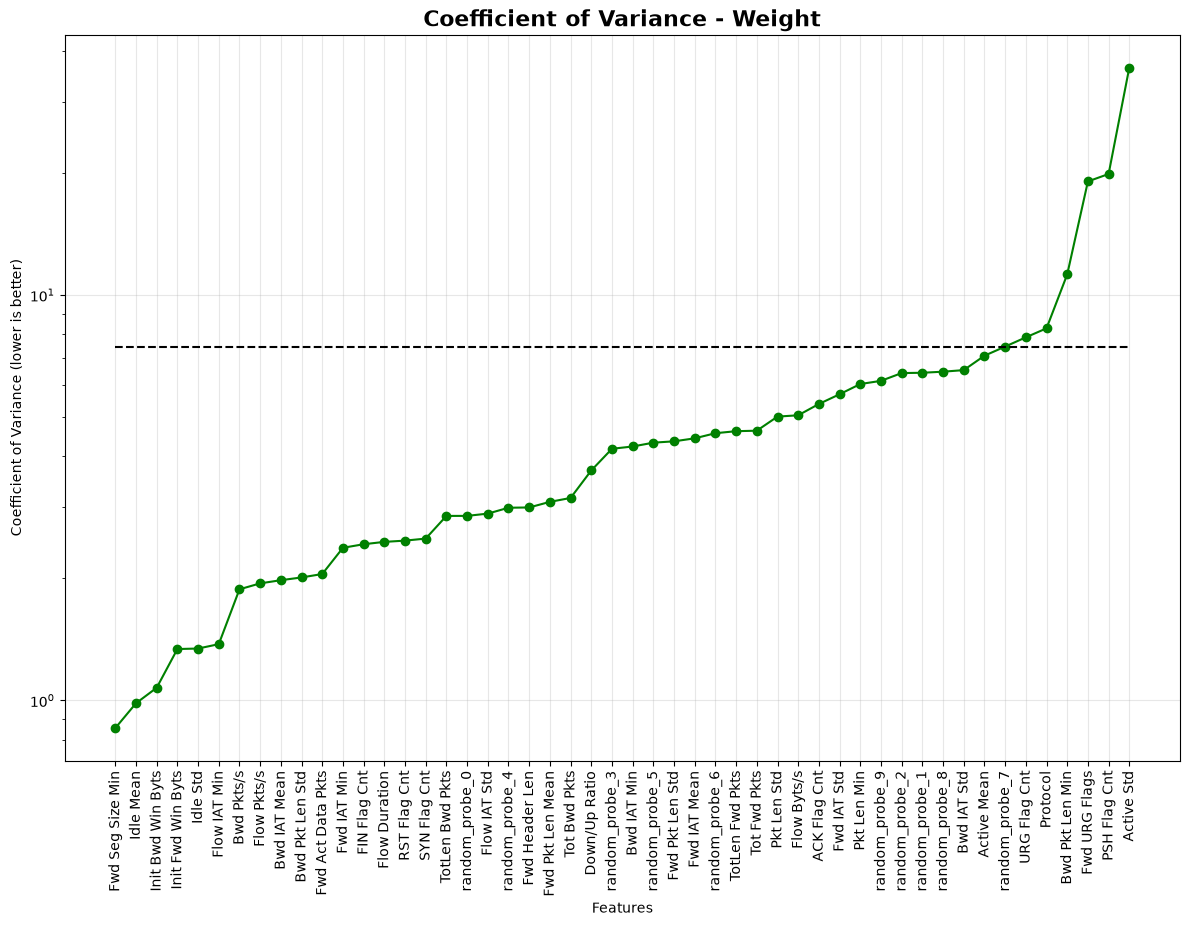

CPU times: user 742 ms, sys: 42.7 ms, total: 784 ms
Wall time: 811 ms


In [74]:
%%time

feature_importance(
    weight_cv_sorted,
    "Coefficient of Variance - Weight",
    "Features",
    "Coefficient of Variance (lower is better)",
    weight_cv_threshold
)

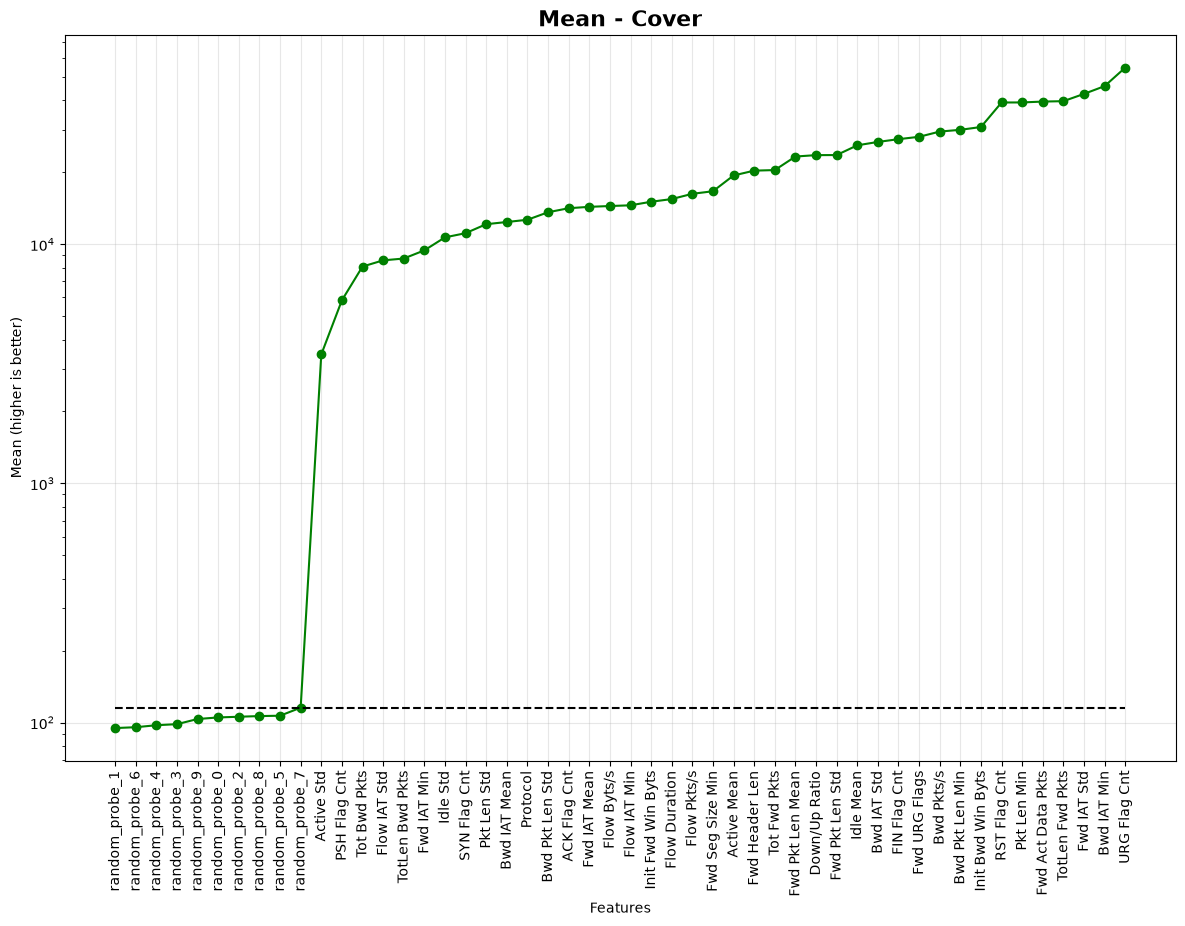

CPU times: user 778 ms, sys: 37.5 ms, total: 816 ms
Wall time: 844 ms


In [75]:
%%time

feature_importance(
    cover_mean_sorted,
    "Mean - Cover",
    "Features",
    "Mean (higher is better)",
    cover_mean_threshold
)

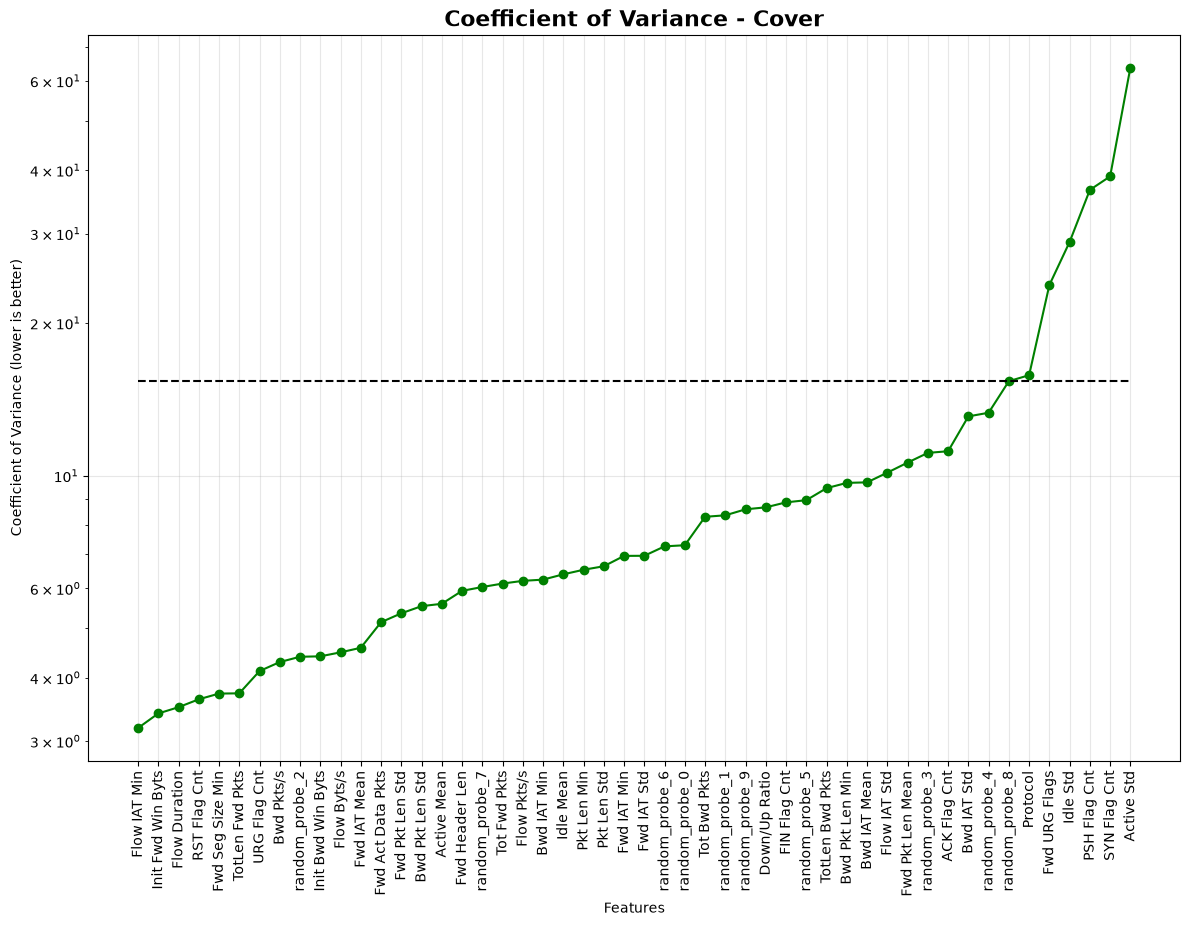

CPU times: user 882 ms, sys: 38.8 ms, total: 921 ms
Wall time: 920 ms


In [76]:
%%time

feature_importance(
    cover_cv_sorted,
    "Coefficient of Variance - Cover",
    "Features",
    "Coefficient of Variance (lower is better)",
    cover_cv_threshold
)

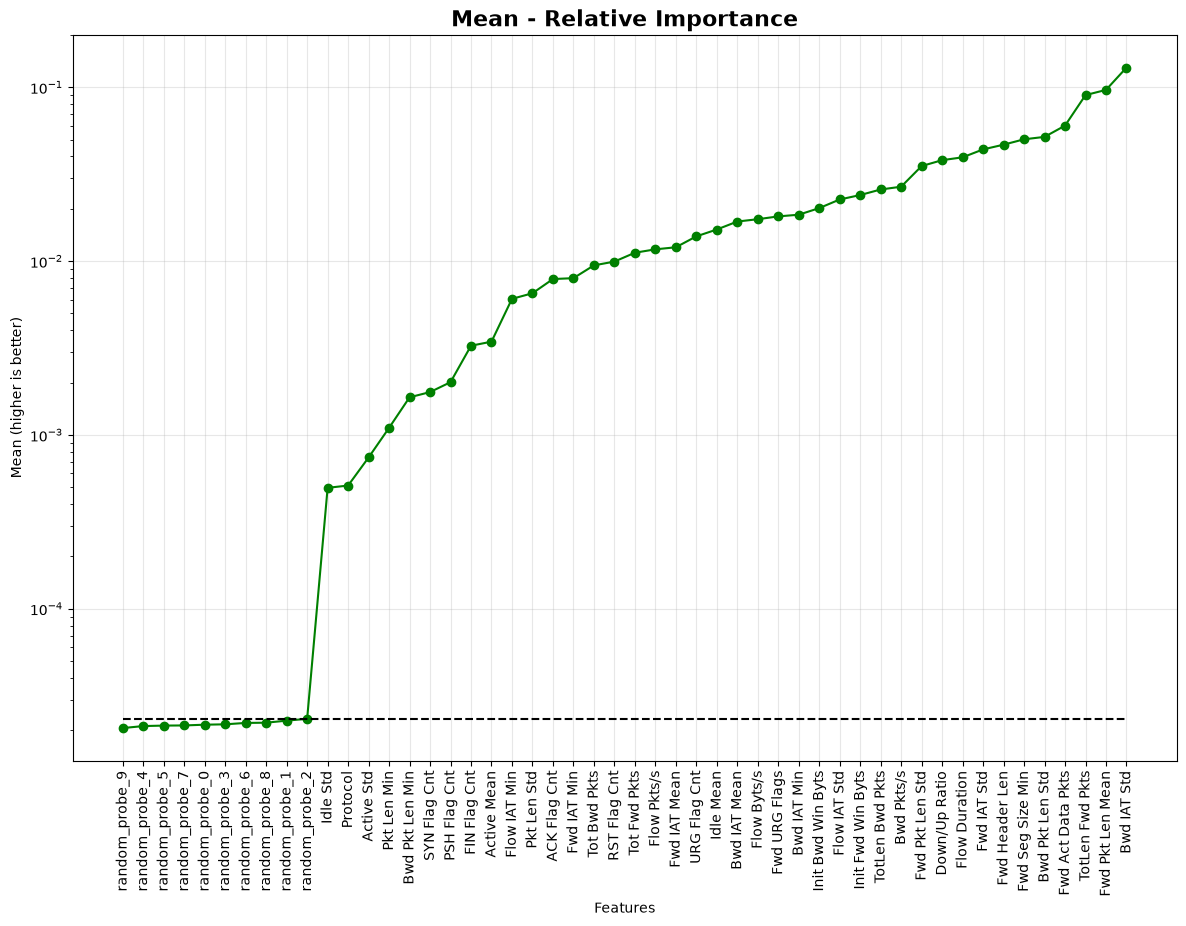

CPU times: user 909 ms, sys: 33.7 ms, total: 942 ms
Wall time: 944 ms


In [77]:
%%time

feature_importance(
    importance_mean_sorted,
    "Mean - Relative Importance",
    "Features",
    "Mean (higher is better)",
    importance_mean_threshold
)

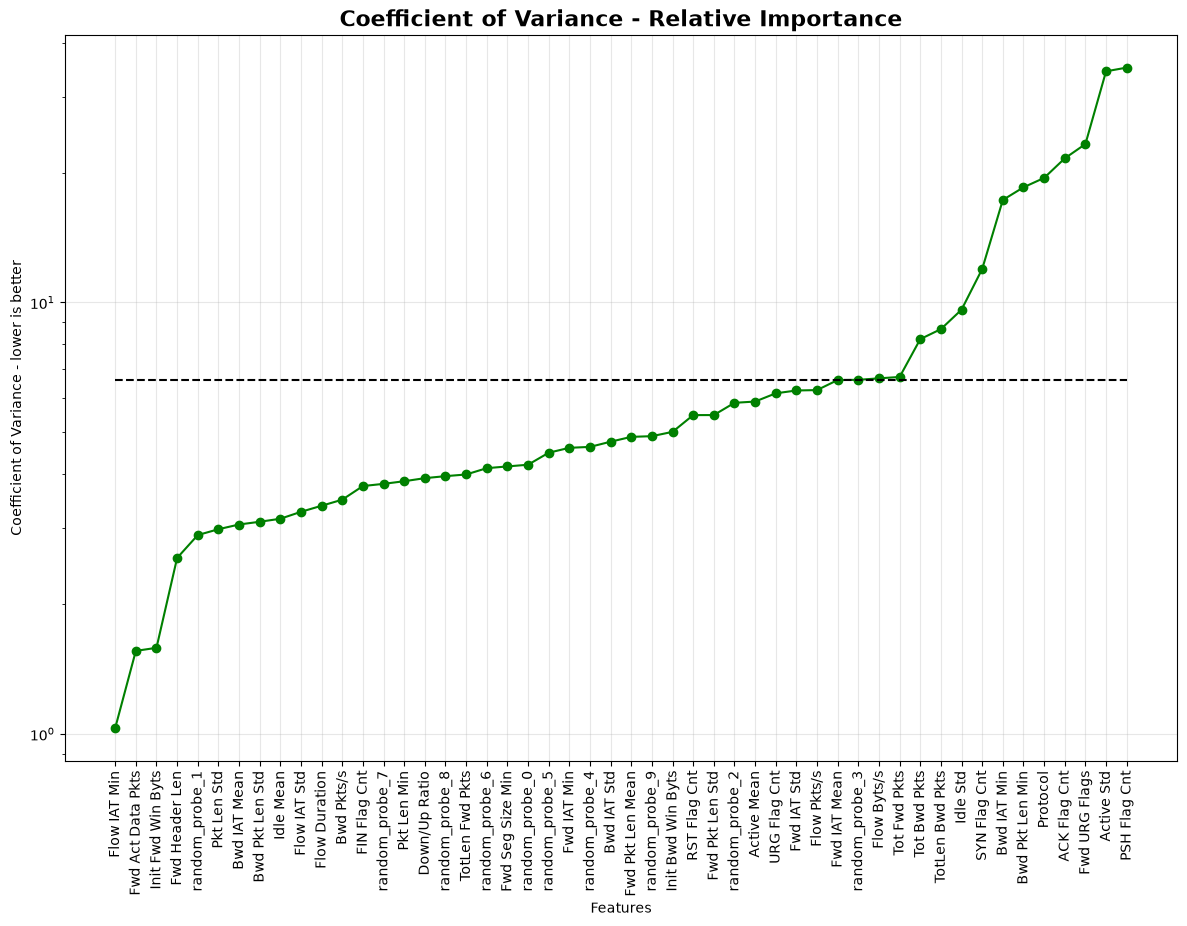

CPU times: user 773 ms, sys: 39.8 ms, total: 813 ms
Wall time: 816 ms


In [78]:
%%time

feature_importance(
    importance_cv_sorted,
    "Coefficient of Variance - Relative Importance",
    "Features",
    "Coefficient of Variance - lower is better",
    importance_cv_threshold
)

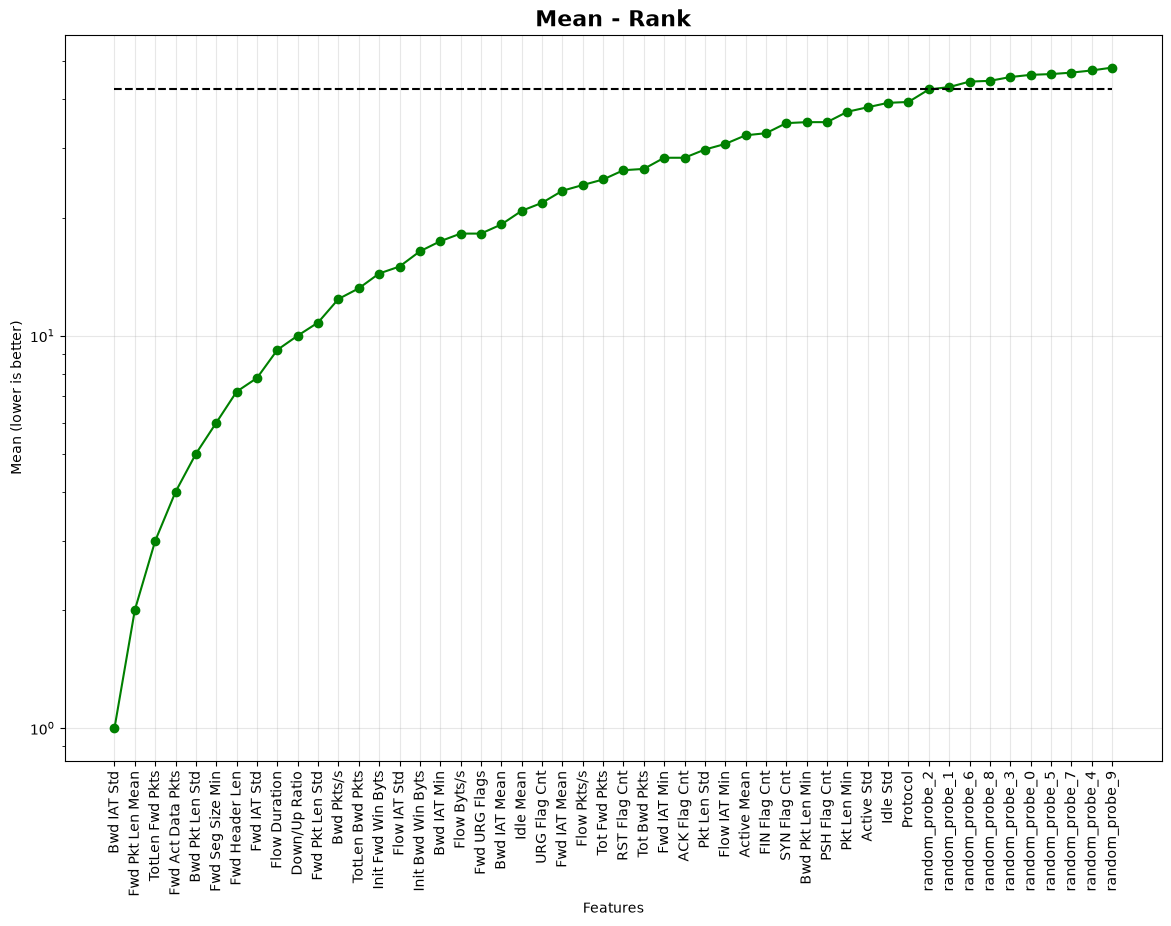

CPU times: user 757 ms, sys: 39.5 ms, total: 797 ms
Wall time: 801 ms


In [101]:
%%time

feature_importance(
    rank_mean_sorted,
    "Mean - Rank",
    "Features",
    "Mean (lower is better)",
    rank_mean_threshold
)

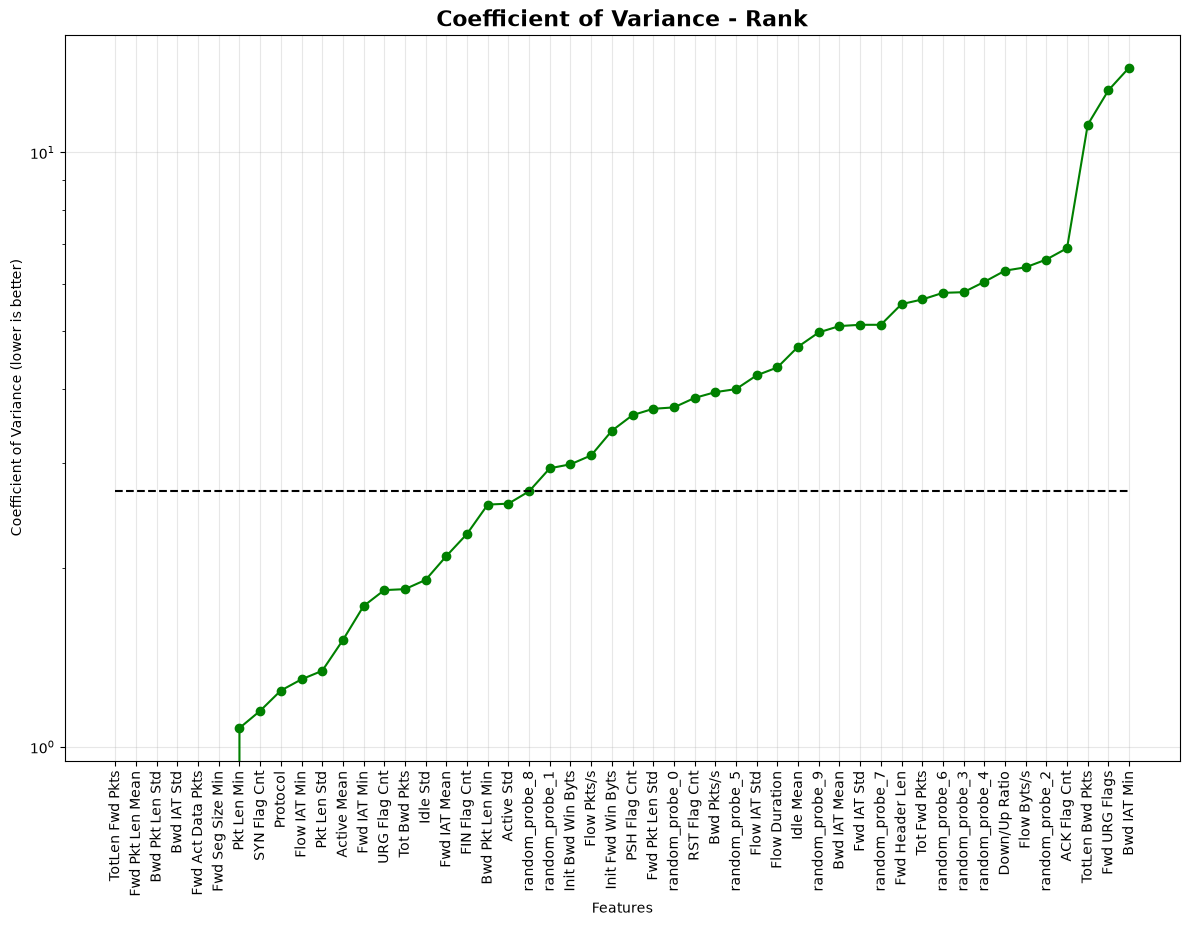

CPU times: user 797 ms, sys: 34.6 ms, total: 831 ms
Wall time: 836 ms


In [102]:
%%time

feature_importance(
    rank_cv_sorted,
    "Coefficient of Variance - Rank",
    "Features",
    "Coefficient of Variance (lower is better)",
    rank_cv_threshold
)

## Scatterplots

In [144]:
gain_scatter, weight_scatter, cover_scatter, importance_scatter, rank_scatter = [{} for x in range(5)]
for key in features.columns:
    gain_scatter[key] = {
        "mean": gain_mean_sorted[key],
        "cv": gain_cv_sorted[key]
    }
    weight_scatter[key] = {
        "mean": weight_mean_sorted[key],
        "cv": weight_cv_sorted[key]
    }
    cover_scatter[key] = {
        "mean": cover_mean_sorted[key],
        "cv": cover_cv_sorted[key]
    }
    importance_scatter[key] = {
        "mean": importance_mean_sorted[key],
        "cv": importance_cv_sorted[key]
    }
    rank_scatter[key] = {
        "mean": rank_mean_sorted[key],
        "cv": rank_cv_sorted[key]
    }

In [145]:
def boolMask(mean_value, cv_value, mean_threshold, cv_threshold):
    """
    Create a boolean mask for mean and coefficient of variation (CV) variables.
    Boolean mask slices a scatter plot into 4 quadrants:
        High mean low CV
        High mean high CV
        Low mean low CV
        low mean high CV
    """
    high_mean_low_cv, high_mean_high_cv, low_mean_low_cv, low_mean_high_cv = [[] for x in range(4)]

    for mean, cv in zip(mean_value, cv_value):
        if (mean > mean_threshold) and (cv < cv_threshold):
            high_mean_low_cv.append(True)
            high_mean_high_cv.append(False)
            low_mean_low_cv.append(False)
            low_mean_high_cv.append(False)
        elif (mean > mean_threshold) and (cv >= cv_threshold):
            high_mean_low_cv.append(False)
            high_mean_high_cv.append(True)
            low_mean_low_cv.append(False)
            low_mean_high_cv.append(False)
        elif (mean <= mean_threshold) and (cv < cv_threshold):
            high_mean_low_cv.append(False)
            high_mean_high_cv.append(False)
            low_mean_low_cv.append(True)
            low_mean_high_cv.append(False)
        elif (mean <= mean_threshold) and (cv >= cv_threshold):
            high_mean_low_cv.append(False)
            high_mean_high_cv.append(False)
            low_mean_low_cv.append(False)
            low_mean_high_cv.append(True)

    return high_mean_low_cv, high_mean_high_cv, low_mean_low_cv, low_mean_high_cv

In [311]:
def scatterPlot(scatter_dict, title, xlabel, ylabel, mean_threshold, cv_threshold):
    """
    Scatter plot between mean and coefficient of variation (CV)
    Scatter plots with 4 quadrants (described in a comment of boolMask function) are computed for 5 variables:
        Gain
        Weight
        Cover
        Relative Importance
        Rank
    """
    mean_values = np.array([scatter_dict[x]["mean"] for x in scatter_dict])
    cv_values = np.array([scatter_dict[x]["cv"] for x in scatter_dict])

    high_mean_low_cv, high_mean_high_cv, low_mean_low_cv, low_mean_high_cv = boolMask(mean_values, cv_values, mean_threshold, cv_threshold)

    fig, ax = plt.subplots(figsize=(12, 8))
    
    ax.scatter(
        mean_values[high_mean_low_cv],
        cv_values[high_mean_low_cv],
        label="High mean / Low CV"
    )

    ax.scatter(
        mean_values[high_mean_high_cv],
        cv_values[high_mean_high_cv],
        label="High mean / High CV"
    )

    ax.scatter(
        mean_values[low_mean_low_cv],
        cv_values[low_mean_low_cv],
        label="Low mean / Low CV"
    )

    ax.scatter(
        mean_values[low_mean_high_cv],
        cv_values[low_mean_high_cv],
        label="Low mean / High CV"
    )

    # Threshold lines
    ax.axvline(
        mean_threshold,
        color="black",
        linestyle="--",
        alpha=0.3
    )

    ax.axhline(
        cv_threshold,
        color="black",
        linestyle="--",
        alpha=0.3
    )

    # Important quadrant
    if title == "Mean and Stability - Rank":
        x0, x1 = 0, mean_threshold
    else:
        x0, x1 = mean_threshold, ax.get_xlim()[1]

    y0, y1 = 0, cv_threshold

    ax.add_patch(
        Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            alpha=0.15
        )
    )
    
    x0, x1 = mean_threshold, ax.get_xlim()[1]
    y0, y1 = 0, cv_threshold
    
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(
        f"{title}",
        fontsize = 16,
        fontweight="bold"
    )
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")

    ax.legend()

    ax.grid(
        True,
        alpha=0.3
    )

    fig.savefig(f"images/{title}.png", bbox_inches="tight")
    
    plt.tight_layout()
    plt.show()

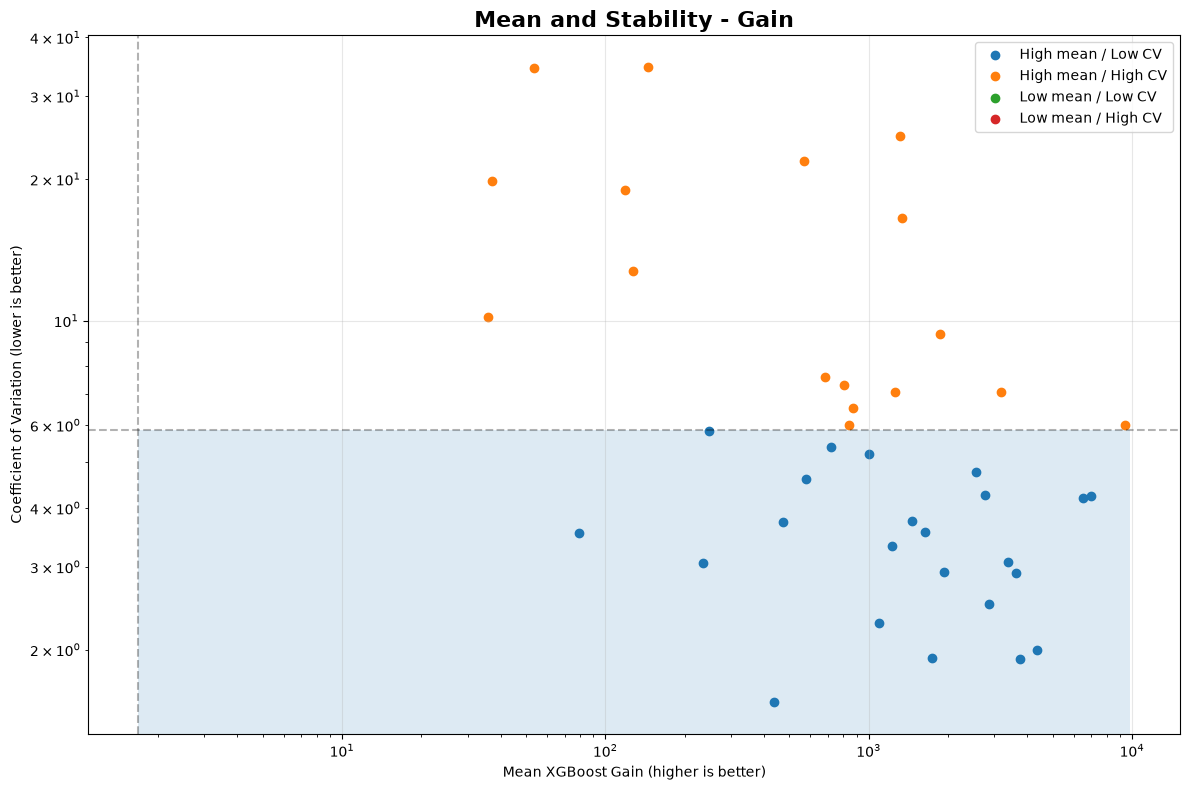

CPU times: user 681 ms, sys: 5.92 ms, total: 686 ms
Wall time: 691 ms


In [312]:
%%time

scatterPlot(
    gain_scatter,
    "Mean and Stability - Gain",
    "Mean XGBoost Gain (higher is better)",
    "Coefficient of Variation (lower is better)",
    gain_mean_threshold,
    gain_cv_threshold
)

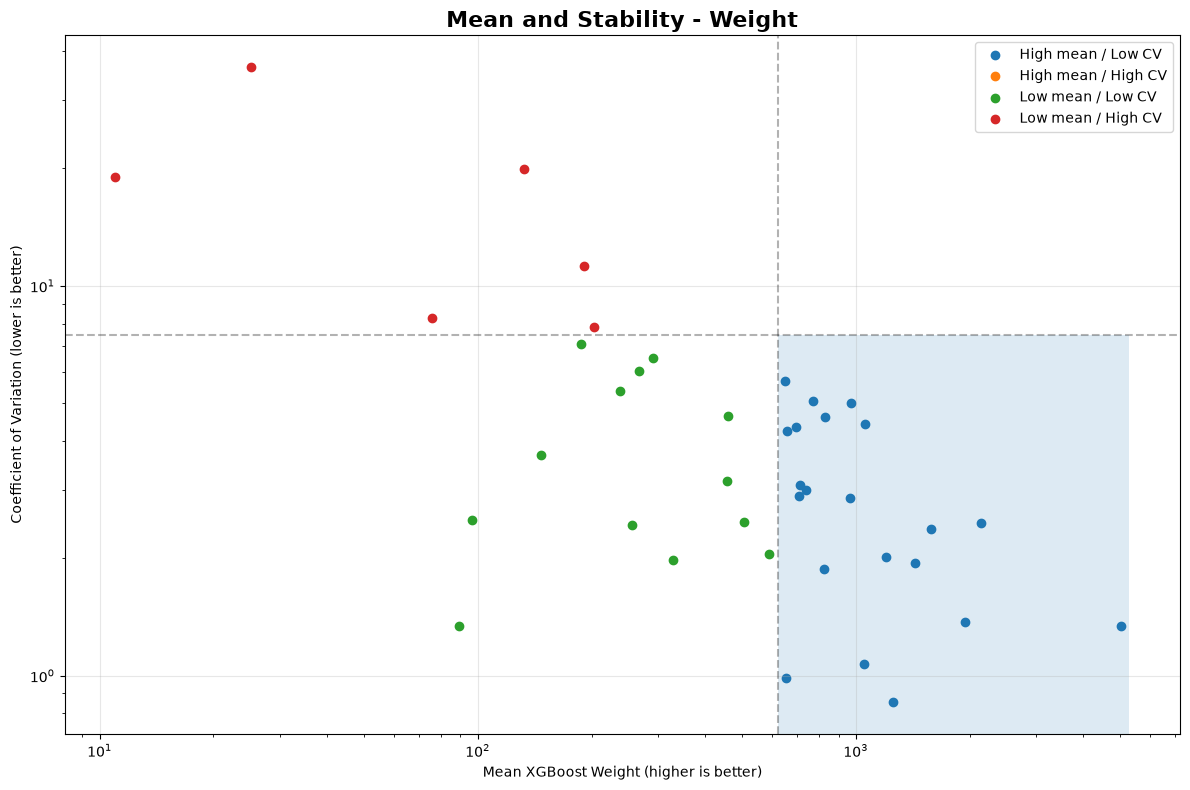

CPU times: user 529 ms, sys: 9.92 ms, total: 539 ms
Wall time: 541 ms


In [313]:
%%time

scatterPlot(
    weight_scatter,
    "Mean and Stability - Weight",
    "Mean XGBoost Weight (higher is better)",
    "Coefficient of Variation (lower is better)",
    weight_mean_threshold,
    weight_cv_threshold
)

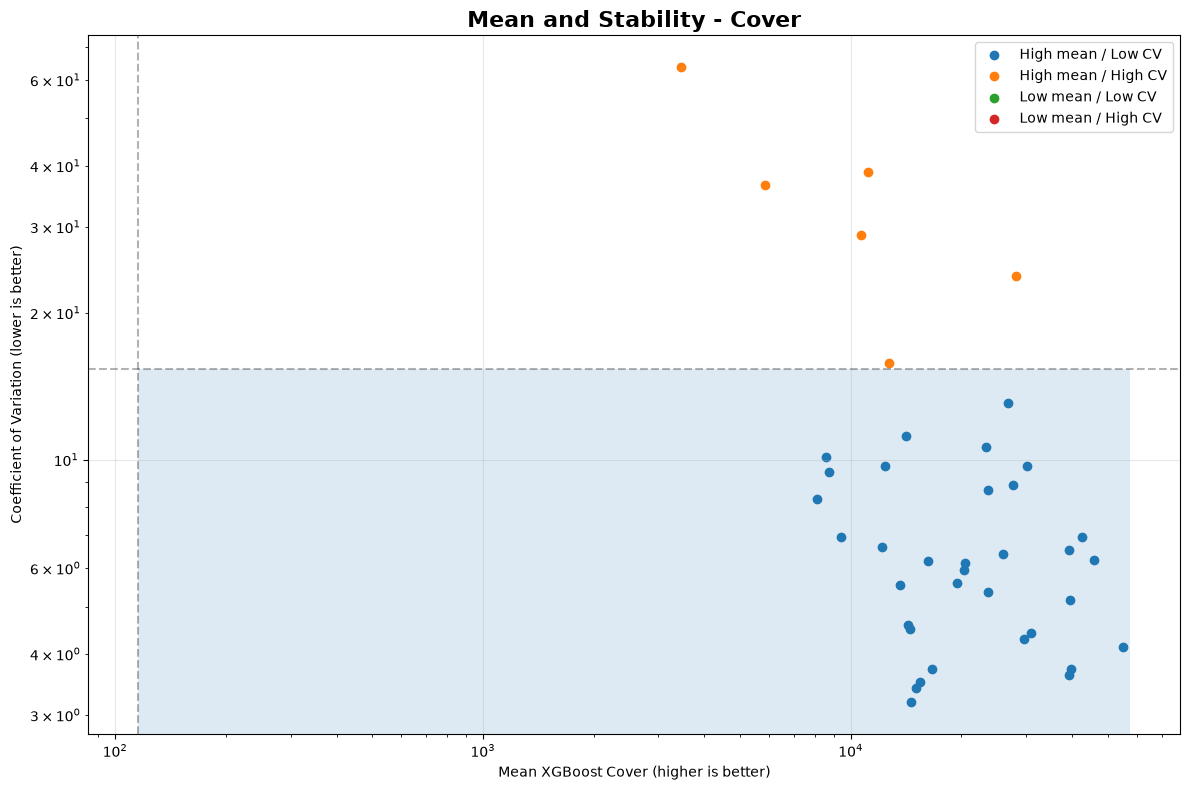

CPU times: user 726 ms, sys: 14.8 ms, total: 741 ms
Wall time: 751 ms


In [314]:
%%time

scatterPlot(
    cover_scatter,
    "Mean and Stability - Cover",
    "Mean XGBoost Cover (higher is better)",
    "Coefficient of Variation (lower is better)",
    cover_mean_threshold,
    cover_cv_threshold
)

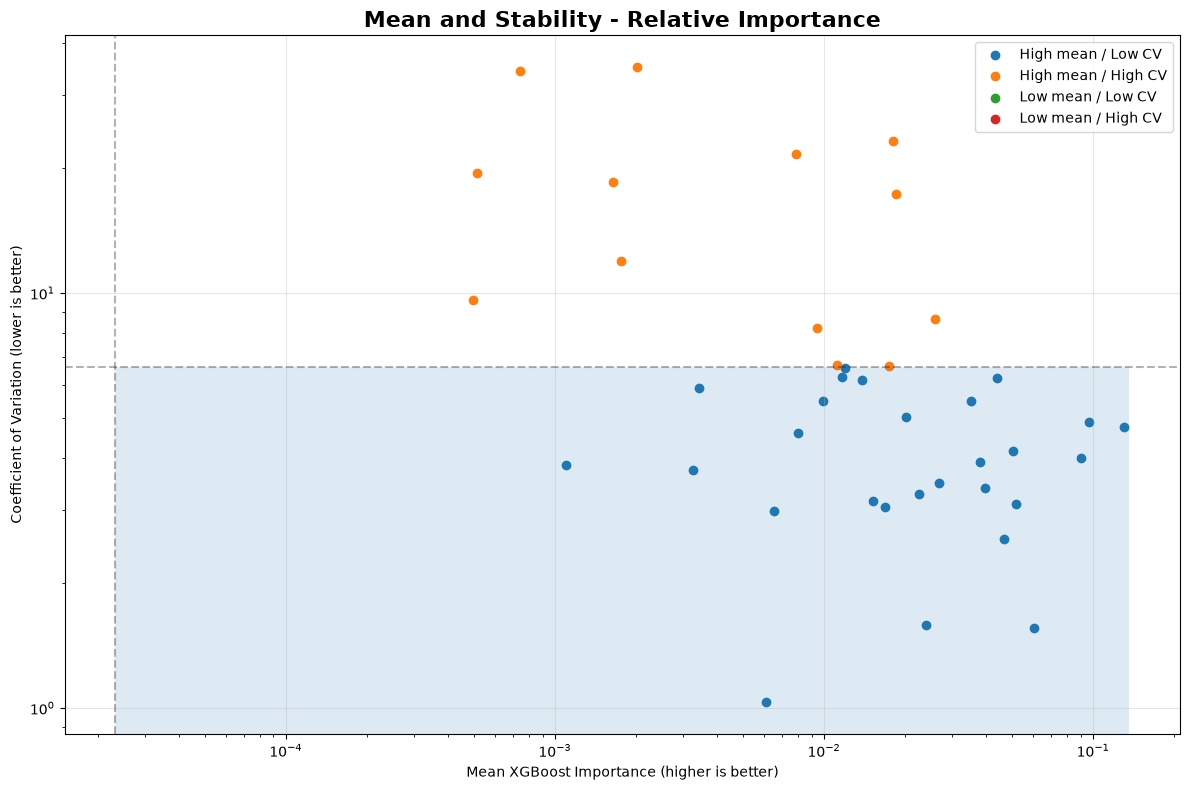

CPU times: user 569 ms, sys: 13.9 ms, total: 583 ms
Wall time: 586 ms


In [315]:
%%time

scatterPlot(
    importance_scatter,
    "Mean and Stability - Relative Importance",
    "Mean XGBoost Importance (higher is better)",
    "Coefficient of Variation (lower is better)",
    importance_mean_threshold,
    importance_cv_threshold
)

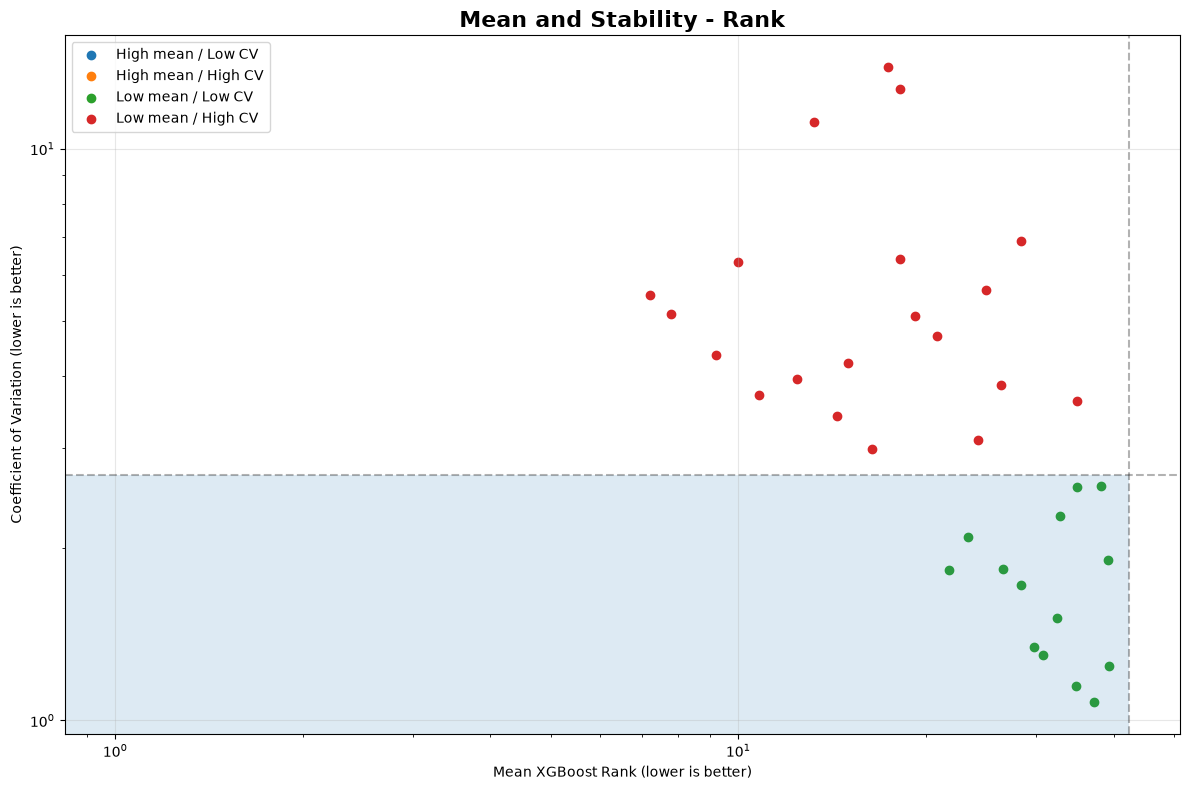

CPU times: user 473 ms, sys: 10.8 ms, total: 484 ms
Wall time: 487 ms


In [316]:
%%time

scatterPlot(
    rank_scatter,
    "Mean and Stability - Rank",
    "Mean XGBoost Rank (lower is better)",
    "Coefficient of Variation (lower is better)",
    rank_mean_threshold,
    rank_cv_threshold
)

## Exporting Descriptive Features

Parse high mean / low CV quadrant values for each parameter from scatterplots. Create a voting mechanism between them for keeping the features (favor gain, weight and cover)

In [89]:
features.drop(random_columns, axis=1, inplace=True)

In [111]:
gain_important_features = [
    feature for feature in features.columns if (gain_scatter[feature]["mean"] > gain_mean_threshold) and (gain_scatter[feature]["cv"] < gain_cv_threshold)
]
weight_important_features = [
    feature for feature in features.columns if (weight_scatter[feature]["mean"] > weight_mean_threshold) and (weight_scatter[feature]["cv"] < weight_cv_threshold)
]
cover_important_features = [
    feature for feature in features.columns if (cover_scatter[feature]["mean"] > cover_mean_threshold) and (cover_scatter[feature]["cv"] < cover_cv_threshold)
]
importance_important_features = [
    feature for feature in features.columns if (importance_scatter[feature]["mean"] > importance_mean_threshold) and (importance_scatter[feature]["cv"] < importance_cv_threshold)
]
rank_important_features = [
    feature for feature in features.columns if (rank_scatter[feature]["mean"] < rank_mean_threshold) and (rank_scatter[feature]["cv"] < rank_cv_threshold)
]

In [112]:
gain_important_features

['Flow Duration',
 'TotLen Fwd Pkts',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Std',
 'Flow IAT Std',
 'Flow IAT Min',
 'Fwd IAT Min',
 'Bwd IAT Mean',
 'Fwd Header Len',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Std',
 'FIN Flag Cnt',
 'RST Flag Cnt',
 'URG Flag Cnt',
 'Down/Up Ratio',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Idle Mean']

In [113]:
weight_important_features

['Flow Duration',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Std',
 'Flow IAT Min',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Min',
 'Bwd IAT Min',
 'Fwd Header Len',
 'Bwd Pkts/s',
 'Pkt Len Std',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Seg Size Min',
 'Idle Mean']

In [114]:
cover_important_features

['Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Std',
 'Flow IAT Min',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Min',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Min',
 'Fwd Header Len',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Std',
 'FIN Flag Cnt',
 'RST Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'Down/Up Ratio',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Idle Mean']

In [115]:
importance_important_features

['Flow Duration',
 'TotLen Fwd Pkts',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Std',
 'Flow Pkts/s',
 'Flow IAT Std',
 'Flow IAT Min',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Min',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Fwd Header Len',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Std',
 'FIN Flag Cnt',
 'RST Flag Cnt',
 'URG Flag Cnt',
 'Down/Up Ratio',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Idle Mean']

In [116]:
rank_important_features

['Protocol',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'Fwd Pkt Len Mean',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Std',
 'Flow IAT Min',
 'Fwd IAT Mean',
 'Fwd IAT Min',
 'Bwd IAT Std',
 'Pkt Len Min',
 'Pkt Len Std',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'URG Flag Cnt',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Active Std',
 'Idle Std']

In [117]:
from collections import Counter

vote_counts = Counter()
for s in (gain_important_features, weight_important_features, cover_important_features, importance_important_features):
    vote_counts.update(s)

final_features = sorted(f for f, count in vote_counts.items() if count >= 3)

final_features

['Active Mean',
 'Bwd IAT Mean',
 'Bwd Pkt Len Std',
 'Bwd Pkts/s',
 'Down/Up Ratio',
 'FIN Flag Cnt',
 'Flow Duration',
 'Flow IAT Min',
 'Flow IAT Std',
 'Flow Pkts/s',
 'Fwd Act Data Pkts',
 'Fwd Header Len',
 'Fwd IAT Mean',
 'Fwd IAT Min',
 'Fwd IAT Std',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Fwd Seg Size Min',
 'Idle Mean',
 'Init Bwd Win Byts',
 'Init Fwd Win Byts',
 'Pkt Len Min',
 'Pkt Len Std',
 'RST Flag Cnt',
 'TotLen Fwd Pkts',
 'URG Flag Cnt']

In [118]:
vote_counts

Counter({'Flow Duration': 4,
         'TotLen Fwd Pkts': 4,
         'Fwd Pkt Len Mean': 4,
         'Fwd Pkt Len Std': 4,
         'Bwd Pkt Len Std': 4,
         'Flow IAT Std': 4,
         'Flow IAT Min': 4,
         'Fwd IAT Min': 4,
         'Fwd Header Len': 4,
         'Bwd Pkts/s': 4,
         'Pkt Len Std': 4,
         'Init Fwd Win Byts': 4,
         'Init Bwd Win Byts': 4,
         'Fwd Seg Size Min': 4,
         'Idle Mean': 4,
         'Bwd IAT Mean': 3,
         'Pkt Len Min': 3,
         'FIN Flag Cnt': 3,
         'RST Flag Cnt': 3,
         'URG Flag Cnt': 3,
         'Down/Up Ratio': 3,
         'Fwd Act Data Pkts': 3,
         'Active Mean': 3,
         'Flow Pkts/s': 3,
         'Fwd IAT Mean': 3,
         'Fwd IAT Std': 3,
         'TotLen Bwd Pkts': 2,
         'Flow Byts/s': 2,
         'Bwd IAT Min': 2,
         'Bwd IAT Std': 2,
         'Tot Fwd Pkts': 1,
         'Tot Bwd Pkts': 1,
         'Bwd Pkt Len Min': 1,
         'ACK Flag Cnt': 1})

In [119]:
print(f"Final feature count: {len(final_features)}")

Final feature count: 26


In [121]:
final_features

['Active Mean',
 'Bwd IAT Mean',
 'Bwd Pkt Len Std',
 'Bwd Pkts/s',
 'Down/Up Ratio',
 'FIN Flag Cnt',
 'Flow Duration',
 'Flow IAT Min',
 'Flow IAT Std',
 'Flow Pkts/s',
 'Fwd Act Data Pkts',
 'Fwd Header Len',
 'Fwd IAT Mean',
 'Fwd IAT Min',
 'Fwd IAT Std',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Fwd Seg Size Min',
 'Idle Mean',
 'Init Bwd Win Byts',
 'Init Fwd Win Byts',
 'Pkt Len Min',
 'Pkt Len Std',
 'RST Flag Cnt',
 'TotLen Fwd Pkts',
 'URG Flag Cnt']

In [126]:
final_features.append('Label')

In [128]:
df[final_features]

,Active Mean,Bwd IAT Mean,Bwd Pkt Len Std,Bwd Pkts/s,Down/Up Ratio,FIN Flag Cnt,Flow Duration,Flow IAT Min,Flow IAT Std,Flow Pkts/s,...,Fwd Seg Size Min,Idle Mean,Init Bwd Win Byts,Init Fwd Win Byts,Pkt Len Min,Pkt Len Std,RST Flag Cnt,TotLen Fwd Pkts,URG Flag Cnt,Label
0,0.0,8569.50000,655.432936,49.510203,0.0,0,141385,1.0,19069.116850,113.166178,...,20,0.0,119,8192,0.0,474.712955,1,553.0,0,Benign
1,0.0,0.00000,0.000000,3558.718861,0.0,0,281,17.0,174.655375,10676.156580,...,20,0.0,0,123,0.0,21.939310,0,38.0,0,Benign
2,0.0,18494.57143,636.314186,53.605123,1.0,0,279824,1.0,24379.448340,92.915547,...,20,0.0,1047,8192,0.0,566.234209,1,1086.0,0,Benign
3,0.0,0.00000,0.000000,0.000000,0.0,0,132,132.0,0.000000,15151.515150,...,20,0.0,-1,256,0.0,0.000000,0,0.0,0,Benign
4,0.0,21082.83333,611.180489,47.442485,1.0,0,274016,1.0,26311.627030,80.287282,...,20,0.0,1047,8192,0.0,497.254764,1,1285.0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10819037,0.0,0.00000,0.000000,50000.000000,1.0,0,20,20.0,0.000000,100000.000000,...,24,0.0,0,65535,0.0,0.000000,0,0.0,0,Infilteration
10819038,0.0,0.00000,0.000000,9.483617,0.0,0,105445,21.0,74531.176060,28.450851,...,20,0.0,0,1024,0.0,0.000000,0,0.0,0,Benign
10819039,0.0,733857.00000,0.000000,2.725241,1.0,0,733880,22.0,423666.844400,5.450482,...,32,0.0,0,8192,0.0,0.000000,0,0.0,0,Benign
10819040,0.0,732708.00000,0.000000,2.729526,1.0,0,732728,20.0,422996.540800,5.459052,...,32,0.0,0,8192,0.0,0.000000,0,0.0,0,Benign


In [129]:
%%time
    
#df[final_features].to_csv("data/final.csv", encoding="utf-8", index=False)

CPU times: user 2min 53s, sys: 1.6 s, total: 2min 54s
Wall time: 2min 56s
